In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ace_tools_open as tools
import matplotlib as mpl
import os

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, ParameterGrid  # Ensure this import is included
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, make_scorer
from sklearn.metrics import roc_curve, auc, roc_auc_score, make_scorer
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, learning_curve, validation_curve
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from skopt.space import Real, Integer, Categorical


# Load the datasets
ewes_path = "ewes.csv"  # Update with your correct file path if necessary
lambs_path = "lambs.csv"  # Update with your correct file path if necessary

ewes_df = pd.read_csv(ewes_path)
lambs_df = pd.read_csv(lambs_path)

## Ranges of values and class imbalance testing

In [27]:
# Define features by type
ewes_categorical = ['breed', 'pregnancies', 'exityear']
ewes_numerical = [
    'birth', 'age', 'longevity', 'years of breeding use', 'lambings', 'stillborn', 'born', 'died',
    'weaned', 'cumweaned', 'avbirthwt', 'av70dwt', 'tot70dwt', 'fertility', 'exitage', 'yearsbarren'
]

lambs_categorical = ['breed', 'mort', 'mortafter2', 'mortbefore70', 'deathsinlitter', 'stillbirth']
lambs_numerical = [
    'lambbirthyear', 'ageatdeath', 'lambbirthtype', 'livelambbirthtype', 'lambraisedtype',
    'lambbirthwt', 'lambday70wt', 'lambgrowthrate', 'eweage', 'longevity'
]

# Function to get categorical levels
def get_levels(df, categorical_features):
    levels = {}
    for feature in categorical_features:
        if feature in df.columns:
            levels[feature] = sorted(df[feature].dropna().unique().tolist())
        else:
            levels[feature] = "Feature not found"
    return levels

# Function to get numerical ranges
def get_ranges(df, numerical_features):
    ranges = {}
    for feature in numerical_features:
        if feature in df.columns:
            min_val = df[feature].min()
            max_val = df[feature].max()
            ranges[feature] = (min_val, max_val)
        else:
            ranges[feature] = "Feature not found"
    return ranges

# Get levels and ranges
ewes_levels = get_levels(ewes_df, ewes_categorical)
ewes_ranges = get_ranges(ewes_df, ewes_numerical)

lambs_levels = get_levels(lambs_df, lambs_categorical)
lambs_ranges = get_ranges(lambs_df, lambs_numerical)

# Display results
print("Ewes categorical feature levels:")
for feature, level in ewes_levels.items():
    print(f"{feature}: {level}")

print("\nEwes numerical feature ranges:")
for feature, range_vals in ewes_ranges.items():
    print(f"{feature}: {range_vals}")

print("\nLambs categorical feature levels:")
for feature, level in lambs_levels.items():
    print(f"{feature}: {level}")

print("\nLambs numerical feature ranges:")
for feature, range_vals in lambs_ranges.items():
    print(f"{feature}: {range_vals}")

Ewes categorical feature levels:
breed: ['SCP', 'bcp', 'suff']
pregnancies: [False, True]
exityear: [0, 1]

Ewes numerical feature ranges:
birth: (np.int64(1996), np.int64(2008))
age: (np.int64(0), np.int64(10))
longevity: (np.float64(1.0), np.float64(10.0))
years of breeding use: (np.float64(1.0), np.float64(9.0))
lambings: (np.float64(0.0), np.float64(9.0))
stillborn: (np.float64(0.0), np.float64(3.0))
born: (np.float64(0.0), np.float64(6.0))
died: (np.float64(0.0), np.float64(4.0))
weaned: (np.float64(0.0), np.float64(6.0))
cumweaned: (np.float64(0.0), np.float64(16.0))
avbirthwt: (np.float64(0.0), np.float64(8.7))
av70dwt: (np.float64(0.0), np.float64(45.4))
tot70dwt: (np.float64(0.0), np.float64(79.1))
fertility: (np.float64(0.0), np.float64(1.0))
exitage: (np.float64(11.0), np.float64(125.0))
yearsbarren: (np.int64(0), np.int64(2))

Lambs categorical feature levels:
breed: ['SCP', 'bcp', 'suff']
mort: [False, True]
mortafter2: [False, True]
mortbefore70: [False, True]
deathsinlit

In [28]:
print(ewes_df["group"].value_counts(normalize=True))
print(lambs_df["eweseroconverted"].value_counts(normalize=True))

group
minus    0.765683
plus     0.234317
Name: proportion, dtype: float64
eweseroconverted
never     0.638571
before    0.203929
during    0.157500
Name: proportion, dtype: float64


## Inclusion of multiple predictors v1

Decided to (1) exclude variables which would not be available at time of diagnosis (such as ewe death/longevity) as those are already indicative of conversion and (2) selected those with predictive power amongst the rest, as decided by a score of 0.15 or more on the heatmap analysis.

Combined Ewes - Predictor Performance (Random Forest)


Combined Lambs - Predictor Performance (Random Forest)


Combined Ewes - Predictor Performance (Logistic Regression)


Combined Lambs - Predictor Performance (Logistic Regression)


Combined Ewes - Predictor Performance (XGBoost)


Combined Lambs - Predictor Performance (XGBoost)


Combined Ewes - Predictor Performance (K-Nearest Neighbors)


Combined Lambs - Predictor Performance (K-Nearest Neighbors)


Combined Ewes - Predictor Performance (Support Vector Machines)


Combined Lambs - Predictor Performance (Support Vector Machines)


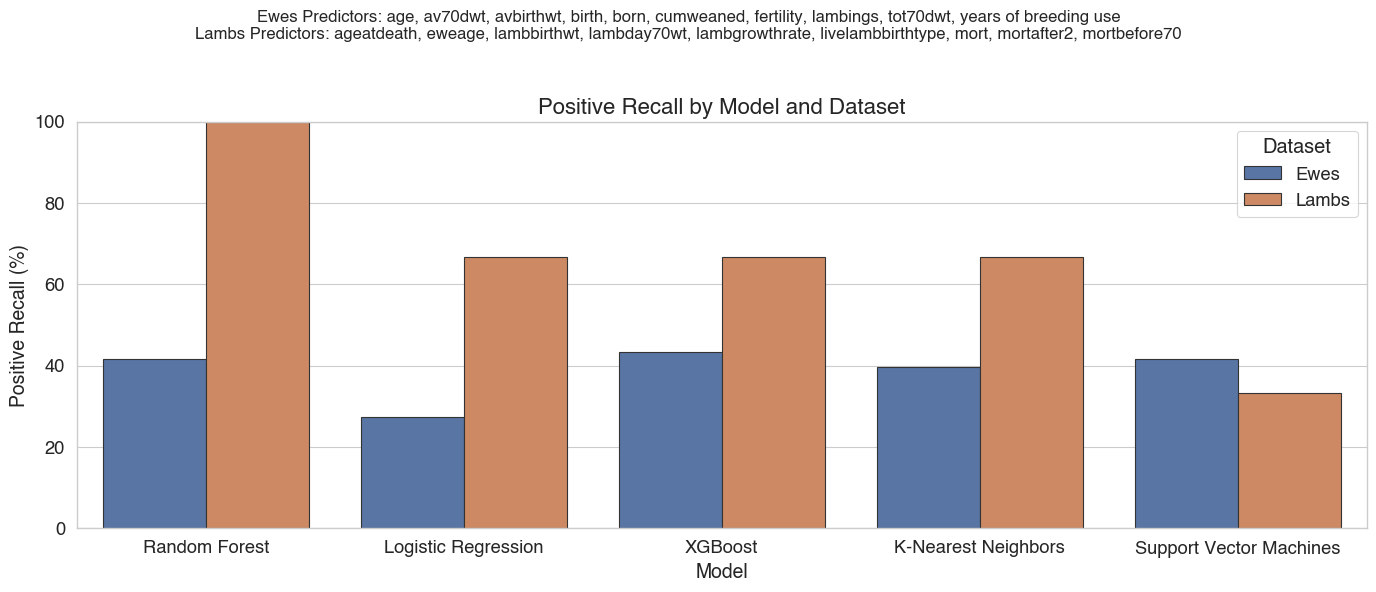

In [29]:
def preprocess_data(df, drop_col, target=None, recode_map=None):
    df = df.drop(columns=[drop_col], errors='ignore')
    if target and recode_map:
        df = df.dropna(subset=[target]).copy()
        df[target + '_binary'] = df[target].map(recode_map)
    return df

# Preprocess datasets
ewes_df = preprocess_data(ewes_df, 'Unnamed: 0', 'group', {'minus': 0, 'plus': 1})
lambs_df = preprocess_data(lambs_df, 'Unnamed: 0', 'eweseroconverted', {'never': 0, 'before': 1, 'during': 1})

# One-liner for valid predictors
valid_predictors = lambda df, excl, tgt: [c for c in df.columns if c not in excl and c != tgt]

def get_model(name):
    models = {
        'random_forest': RandomForestClassifier(random_state=42),
        'logistic_regression': LogisticRegression(random_state=42, max_iter=1000),
        'xgboost': XGBClassifier(random_state=42, eval_metric='logloss'),
        'knn': KNeighborsClassifier(n_neighbors=5),
        'svm': SVC(random_state=42)
    }
    return models.get(name)

def test_combined_predictors(df, predictors, target, model, param_grid=None):
    d = df.dropna(subset=predictors + [target]).copy()
    for col in predictors:
        if d[col].dtype == 'object':
            d[col] = d[col].astype('category').cat.codes
    X_train, X_test, y_train, y_test = train_test_split(
        d[predictors], d[target], test_size=0.2, random_state=42, stratify=d[target]
    )
    if param_grid:
        scorer = make_scorer(recall_score, pos_label=1)
        grid = GridSearchCV(model, param_grid, cv=10, scoring=scorer, n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model, best_params = grid.best_estimator_, grid.best_params_
    else:
        model.fit(X_train, y_train)
        best_model, best_params = model, "N/A"
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)
    rec_neg = (cm[0, 0] / cm[0].sum() * 100) if cm[0].sum() else 0
    rec_pos = (cm[1, 1] / cm[1].sum() * 100) if cm[1].sum() else 0
    predictors_str = ", ".join(predictors)
    return pd.DataFrame([[predictors_str, len(d), acc, rec_neg, rec_pos, best_params]],
                        columns=["Predictors", "Sample Size", "Accuracy (%)", 
                                 "Recall for Negative (0) (%)", "Recall for Positive (1) (%)", "Best Params"])

def run_model_test_combined(model_name, display_name, preds_ewes, preds_lambs, param_grid=None):
    model = get_model(model_name)
    e_res = test_combined_predictors(ewes_df, preds_ewes, 'group_binary', model, param_grid)
    l_res = test_combined_predictors(lambs_df, preds_lambs, 'eweseroconverted_binary', model, param_grid)
    e_res['Dataset'], l_res['Dataset'] = 'Ewes', 'Lambs'
    comb = pd.concat([e_res, l_res], keys=['Ewes', 'Lambs'])
    comb['Model'] = display_name
    comb['Accuracy (%)'] = comb['Accuracy (%)'].map("{:.2f}%".format)
    tools.display_dataframe_to_user(name=f"Combined Ewes - Predictor Performance ({display_name})", dataframe=e_res)
    tools.display_dataframe_to_user(name=f"Combined Lambs - Predictor Performance ({display_name})", dataframe=l_res)
    return comb

# Define parameter grids and predictors
param_grids = {
    'random_forest': {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]},
    'logistic_regression': {'C': [0.1, 1, 10], 'solver': ['liblinear']},
    'xgboost': {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]},
    'knn': {'n_neighbors': [3, 5, 7]},
    'svm': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}

repro_predictors_ewes = ['age', 'av70dwt', 'avbirthwt', 'birth', 'born', 'cumweaned', 'fertility', 'lambings', 'tot70dwt', 'years of breeding use']
repro_predictors_lambs = ['ageatdeath', 'eweage', 'lambbirthwt', 'lambday70wt', 'lambgrowthrate', 'livelambbirthtype', 'mort', 'mortafter2', 'mortbefore70']

# Run tests for each model
combined_results_rf_repro  = run_model_test_combined('random_forest',       'Random Forest',       repro_predictors_ewes, repro_predictors_lambs, param_grids['random_forest'])
combined_results_lr_repro  = run_model_test_combined('logistic_regression', 'Logistic Regression', repro_predictors_ewes, repro_predictors_lambs, param_grids['logistic_regression'])
combined_results_xgb_repro = run_model_test_combined('xgboost',             'XGBoost',             repro_predictors_ewes, repro_predictors_lambs, param_grids['xgboost'])
combined_results_knn_repro = run_model_test_combined('knn',                 'K-Nearest Neighbors', repro_predictors_ewes, repro_predictors_lambs, param_grids['knn'])
combined_results_svm_repro = run_model_test_combined('svm',                 'Support Vector Machines', repro_predictors_ewes, repro_predictors_lambs, param_grids['svm'])
combined_repro_df = pd.concat([combined_results_rf_repro, combined_results_lr_repro, combined_results_xgb_repro,
                               combined_results_knn_repro, combined_results_svm_repro])

# Plotting
sns.set_theme(style="whitegrid", context="paper", font="Helvetica", font_scale=1.5)
plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Recall for Positive (1) (%)', hue='Dataset',
            data=combined_repro_df, palette="deep", edgecolor=".2", err_kws={'linewidth': 1.5})
plt.xlabel("Model", fontsize=14)
plt.ylabel("Positive Recall (%)", fontsize=14)
plt.title("Positive Recall by Model and Dataset", fontsize=16, weight='bold')
plt.ylim(0, 100)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.suptitle(
    f"Ewes Predictors: {', '.join(sorted(repro_predictors_ewes))}\nLambs Predictors: {', '.join(sorted(repro_predictors_lambs))}",
    fontsize=12, y=0.99
)
plt.savefig("Positive_Recall_Publication_NewPredictors.png", dpi=300)
plt.show()


Reason positive recall perfect using lamb predictors in Random Forest model is variable ageatdeath. It is missing for most rows which makes the lamb sample size tiny at only n=32, which explains those fantastic results but is not reliable.

##  Inclusion of multiple predictors v2 -- **working model**

Included changes discussed in v1 and added a barchart plot with negative recall to analyze overall performance. Added a threshold the classification algorithm uses for decision making so the user can change the balance of true positives and false positives as needed (currently set to 0.25 to optimize for TP).

Combined Ewes - Predictor Performance (Random Forest)


Combined Lambs - Predictor Performance (Random Forest)


Combined Ewes - Predictor Performance (Logistic Regression)


Combined Lambs - Predictor Performance (Logistic Regression)


Combined Ewes - Predictor Performance (XGBoost)


Combined Lambs - Predictor Performance (XGBoost)


Combined Ewes - Predictor Performance (K-Nearest Neighbors)


Combined Lambs - Predictor Performance (K-Nearest Neighbors)


Combined Ewes - Predictor Performance (Support Vector Machines)


Combined Lambs - Predictor Performance (Support Vector Machines)


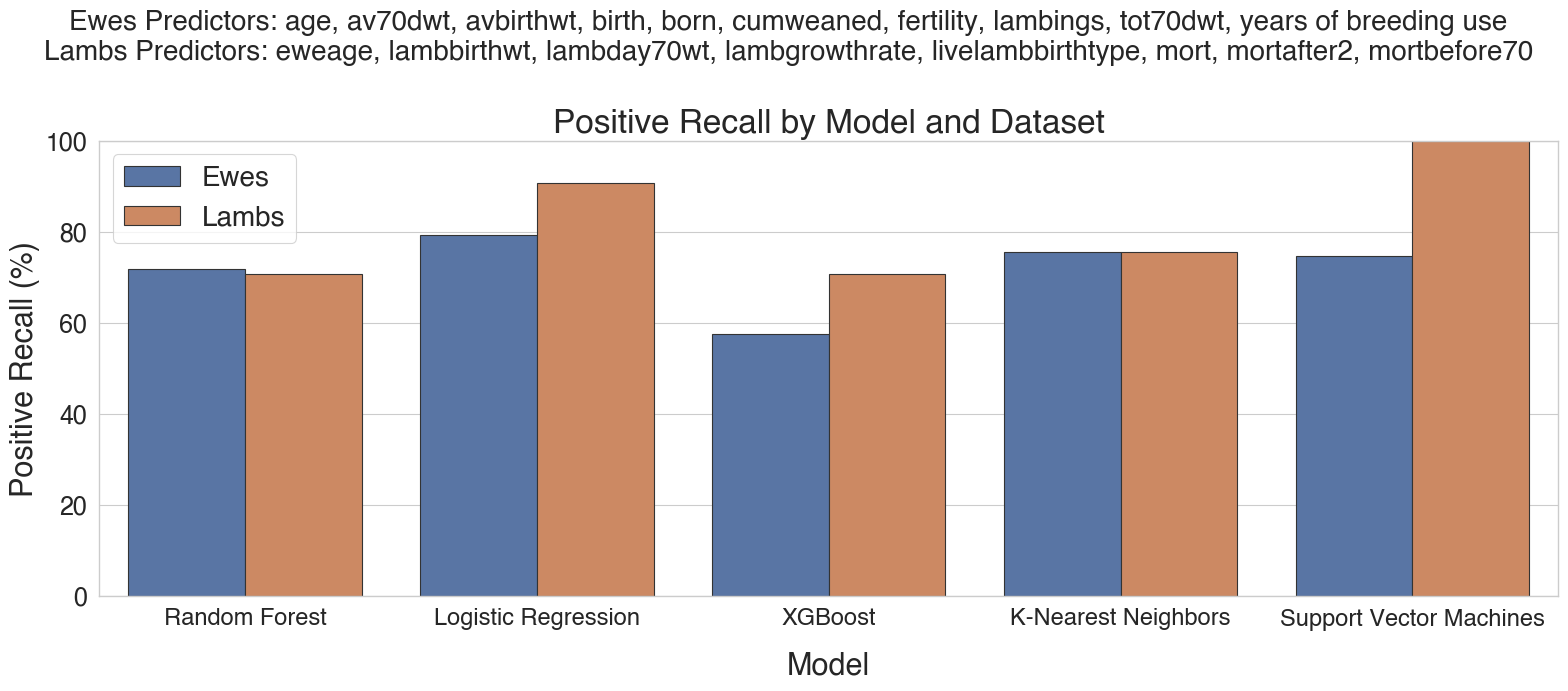

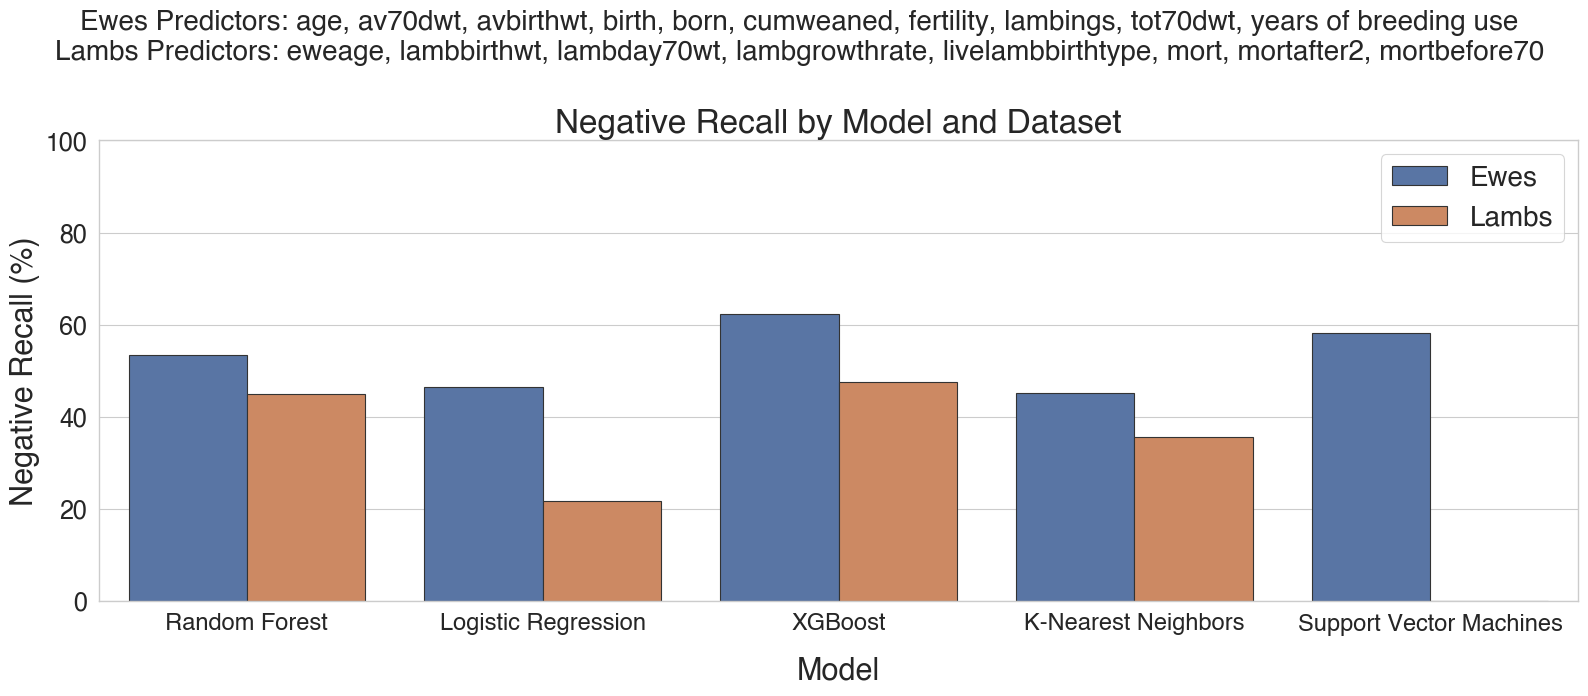

In [5]:
# --- Data Preprocessing Function ---
def preprocess_data(df, drop_col, target=None, recode_map=None):
    # Drop the unwanted column and create a binary target if specified
    df = df.drop(columns=[drop_col], errors='ignore')
    if target and recode_map:
        df = df.dropna(subset=[target]).copy()
        df[target + '_binary'] = df[target].map(recode_map)
    return df

# Preprocess both datasets
ewes_df = preprocess_data(ewes_df, 'Unnamed: 0', 'group', {'minus': 0, 'plus': 1})
lambs_df = preprocess_data(lambs_df, 'Unnamed: 0', 'eweseroconverted', {'never': 0, 'before': 1, 'during': 1})

# --- Model Factory Function ---
def get_model(name, **kw):
    name = name.lower()
    if name == 'random_forest':
        return RandomForestClassifier(random_state=42, **kw)
    elif name == 'logistic_regression':
        return LogisticRegression(random_state=42, max_iter=1000, **kw)
    elif name == 'xgboost':
        return XGBClassifier(random_state=42, eval_metric='logloss', **kw)
    elif name == 'knn':
        return KNeighborsClassifier(**kw)
    elif name == 'svm':
        return SVC(random_state=42, probability=True, **kw)
    else:
        raise ValueError(f"Model name '{name}' is not recognized.")

# --- Testing Function for Combined Predictors ---
def test_combined_predictors(df, preds, target, model, param_grid=None, ret=False):
    # Clean data, encode categorical predictors, and split into training and test sets
    d = df.dropna(subset=preds + [target]).copy()
    for col in preds:
        if d[col].dtype == 'object': 
            d[col] = d[col].astype('category').cat.codes
    X_tr, X_te, y_tr, y_te = train_test_split(d[preds], d[target], test_size=0.2, random_state=42, stratify=d[target])
    # Use grid search if a parameter grid is provided
    if param_grid:
        grid = GridSearchCV(model, param_grid, cv=10, scoring=make_scorer(recall_score, pos_label=1), n_jobs=-1)
        grid.fit(X_tr, y_tr)
        best_model, best_params = grid.best_estimator_, grid.best_params_
    else:
        model.fit(X_tr, y_tr)
        best_model, best_params = model, "N/A"
    # Predict using a fixed threshold and compute performance metrics
    y_pred = (best_model.predict_proba(X_te)[:, 1] > 0.25).astype(int)
    acc = accuracy_score(y_te, y_pred) * 100
    cm = confusion_matrix(y_te, y_pred)
    rn = (cm[0, 0] / cm[0].sum() * 100) if cm[0].sum() else 0
    rp = (cm[1, 1] / cm[1].sum() * 100) if cm[1].sum() else 0
    res = pd.DataFrame([[", ".join(preds), len(d), acc, rn, rp, best_params]],
                       columns=["Predictors", "Sample Size", "Accuracy (%)",
                                "Recall for Negative (0) (%)", "Recall for Positive (1) (%)", "Best Params"])
    return (res, best_model, X_te, y_te) if ret else res

# --- Combined Model Test Function ---
def run_model_test_combined(m_name, disp, p_ewes, p_lambs, param_grid=None, **kw):
    # Run tests on both datasets and display results
    mdl = get_model(m_name, **kw)
    e_res = test_combined_predictors(ewes_df, p_ewes, 'group_binary', mdl, param_grid)
    l_res = test_combined_predictors(lambs_df, p_lambs, 'eweseroconverted_binary', mdl, param_grid)
    e_res['Dataset'], l_res['Dataset'] = 'Ewes', 'Lambs'
    comb = pd.concat([e_res, l_res], ignore_index=True)
    comb['Model'] = disp
    comb['Accuracy (%)'] = comb['Accuracy (%)'].map("{:.2f}%".format)
    tools.display_dataframe_to_user(name=f"Combined Ewes - Predictor Performance ({disp})", dataframe=e_res)
    tools.display_dataframe_to_user(name=f"Combined Lambs - Predictor Performance ({disp})", dataframe=l_res)
    return comb

# --- Parameter Grids and Predictor Definitions ---
param_grids = {
    'random_forest': {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]},
    'logistic_regression': {'C': [0.1, 1, 10], 'solver': ['liblinear']},
    'xgboost': {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]},
    'knn': {'n_neighbors': [3, 5, 7]},
    'svm': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}
repro_predictors_ewes = ['age', 'av70dwt', 'avbirthwt', 'birth', 'born',
                           'cumweaned', 'fertility', 'lambings', 'tot70dwt', 'years of breeding use']
repro_predictors_lambs = ['eweage', 'lambbirthwt', 'lambday70wt', 'lambgrowthrate',
                          'livelambbirthtype', 'mort', 'mortafter2', 'mortbefore70']

# --- Run Model Tests for Each Model ---
crf = run_model_test_combined('random_forest', 'Random Forest', repro_predictors_ewes, repro_predictors_lambs, param_grids['random_forest'])
clr = run_model_test_combined('logistic_regression', 'Logistic Regression', repro_predictors_ewes, repro_predictors_lambs, param_grids['logistic_regression'])
cxgb = run_model_test_combined('xgboost', 'XGBoost', repro_predictors_ewes, repro_predictors_lambs, param_grids['xgboost'])
cknn = run_model_test_combined('knn', 'K-Nearest Neighbors', repro_predictors_ewes, repro_predictors_lambs, param_grids['knn'])
csvm = run_model_test_combined('svm', 'Support Vector Machines', repro_predictors_ewes, repro_predictors_lambs, param_grids['svm'])
combined_repro_df = pd.concat([crf, clr, cxgb, cknn, csvm], ignore_index=True)

# --- Plotting Positive Recall ---
pt = f"Ewes Predictors: {', '.join(sorted(repro_predictors_ewes))}\nLambs Predictors: {', '.join(sorted(repro_predictors_lambs))}"
sns.set_theme(style="whitegrid", context="paper", font="Helvetica", font_scale=1.5)
plt.figure(figsize=(16, 7))
# Barplot for positive recall performance
sns.barplot(x='Model', y='Recall for Positive (1) (%)', hue='Dataset', data=combined_repro_df,
            palette="deep", edgecolor=".2", err_kws={'linewidth': 1.5})
plt.xlabel("Model", fontsize=22,labelpad=15); plt.ylabel("Positive Recall (%)", fontsize=22)
plt.title("Positive Recall by Model and Dataset", fontsize=24, weight='bold'); plt.ylim(0, 100)
plt.xticks(fontsize=17)
plt.legend(fontsize=20, title_fontsize=20)
plt.yticks(fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.88]); plt.suptitle(pt, fontsize=20, y=0.99)
plt.savefig("/Users/davidcalleja/Desktop/THESIS/analysis/figures/Positive_Recall_NewPredictors.png", dpi=300)
plt.show()

# --- Plotting Negative Recall ---
plt.figure(figsize=(16, 7))
# Barplot for negative recall performance
sns.barplot(x='Model', y='Recall for Negative (0) (%)', hue='Dataset', data=combined_repro_df,
            palette="deep", edgecolor=".2", err_kws={'linewidth': 1.5})
plt.xlabel("Model", fontsize=22, labelpad=15); plt.ylabel("Negative Recall (%)", fontsize=22)
plt.title("Negative Recall by Model and Dataset", fontsize=24, weight='bold'); plt.ylim(0, 100)
plt.tight_layout(rect=[0, 0, 1, 0.88]); plt.suptitle(pt, fontsize=20, y=0.99)
plt.xticks(fontsize=17)
plt.legend(fontsize=20, title_fontsize=20)
plt.yticks(fontsize=18)
plt.savefig("/Users/davidcalleja/Desktop/THESIS/analysis/figures/Negative_Recall_NewPredictors.png", dpi=300)
plt.show()


## ROC curves

Now, we want to plot ROC curves to get a better grasp of what TP/FP ratio we can achieve by changing the threshold and understanding how accurate our model is. 

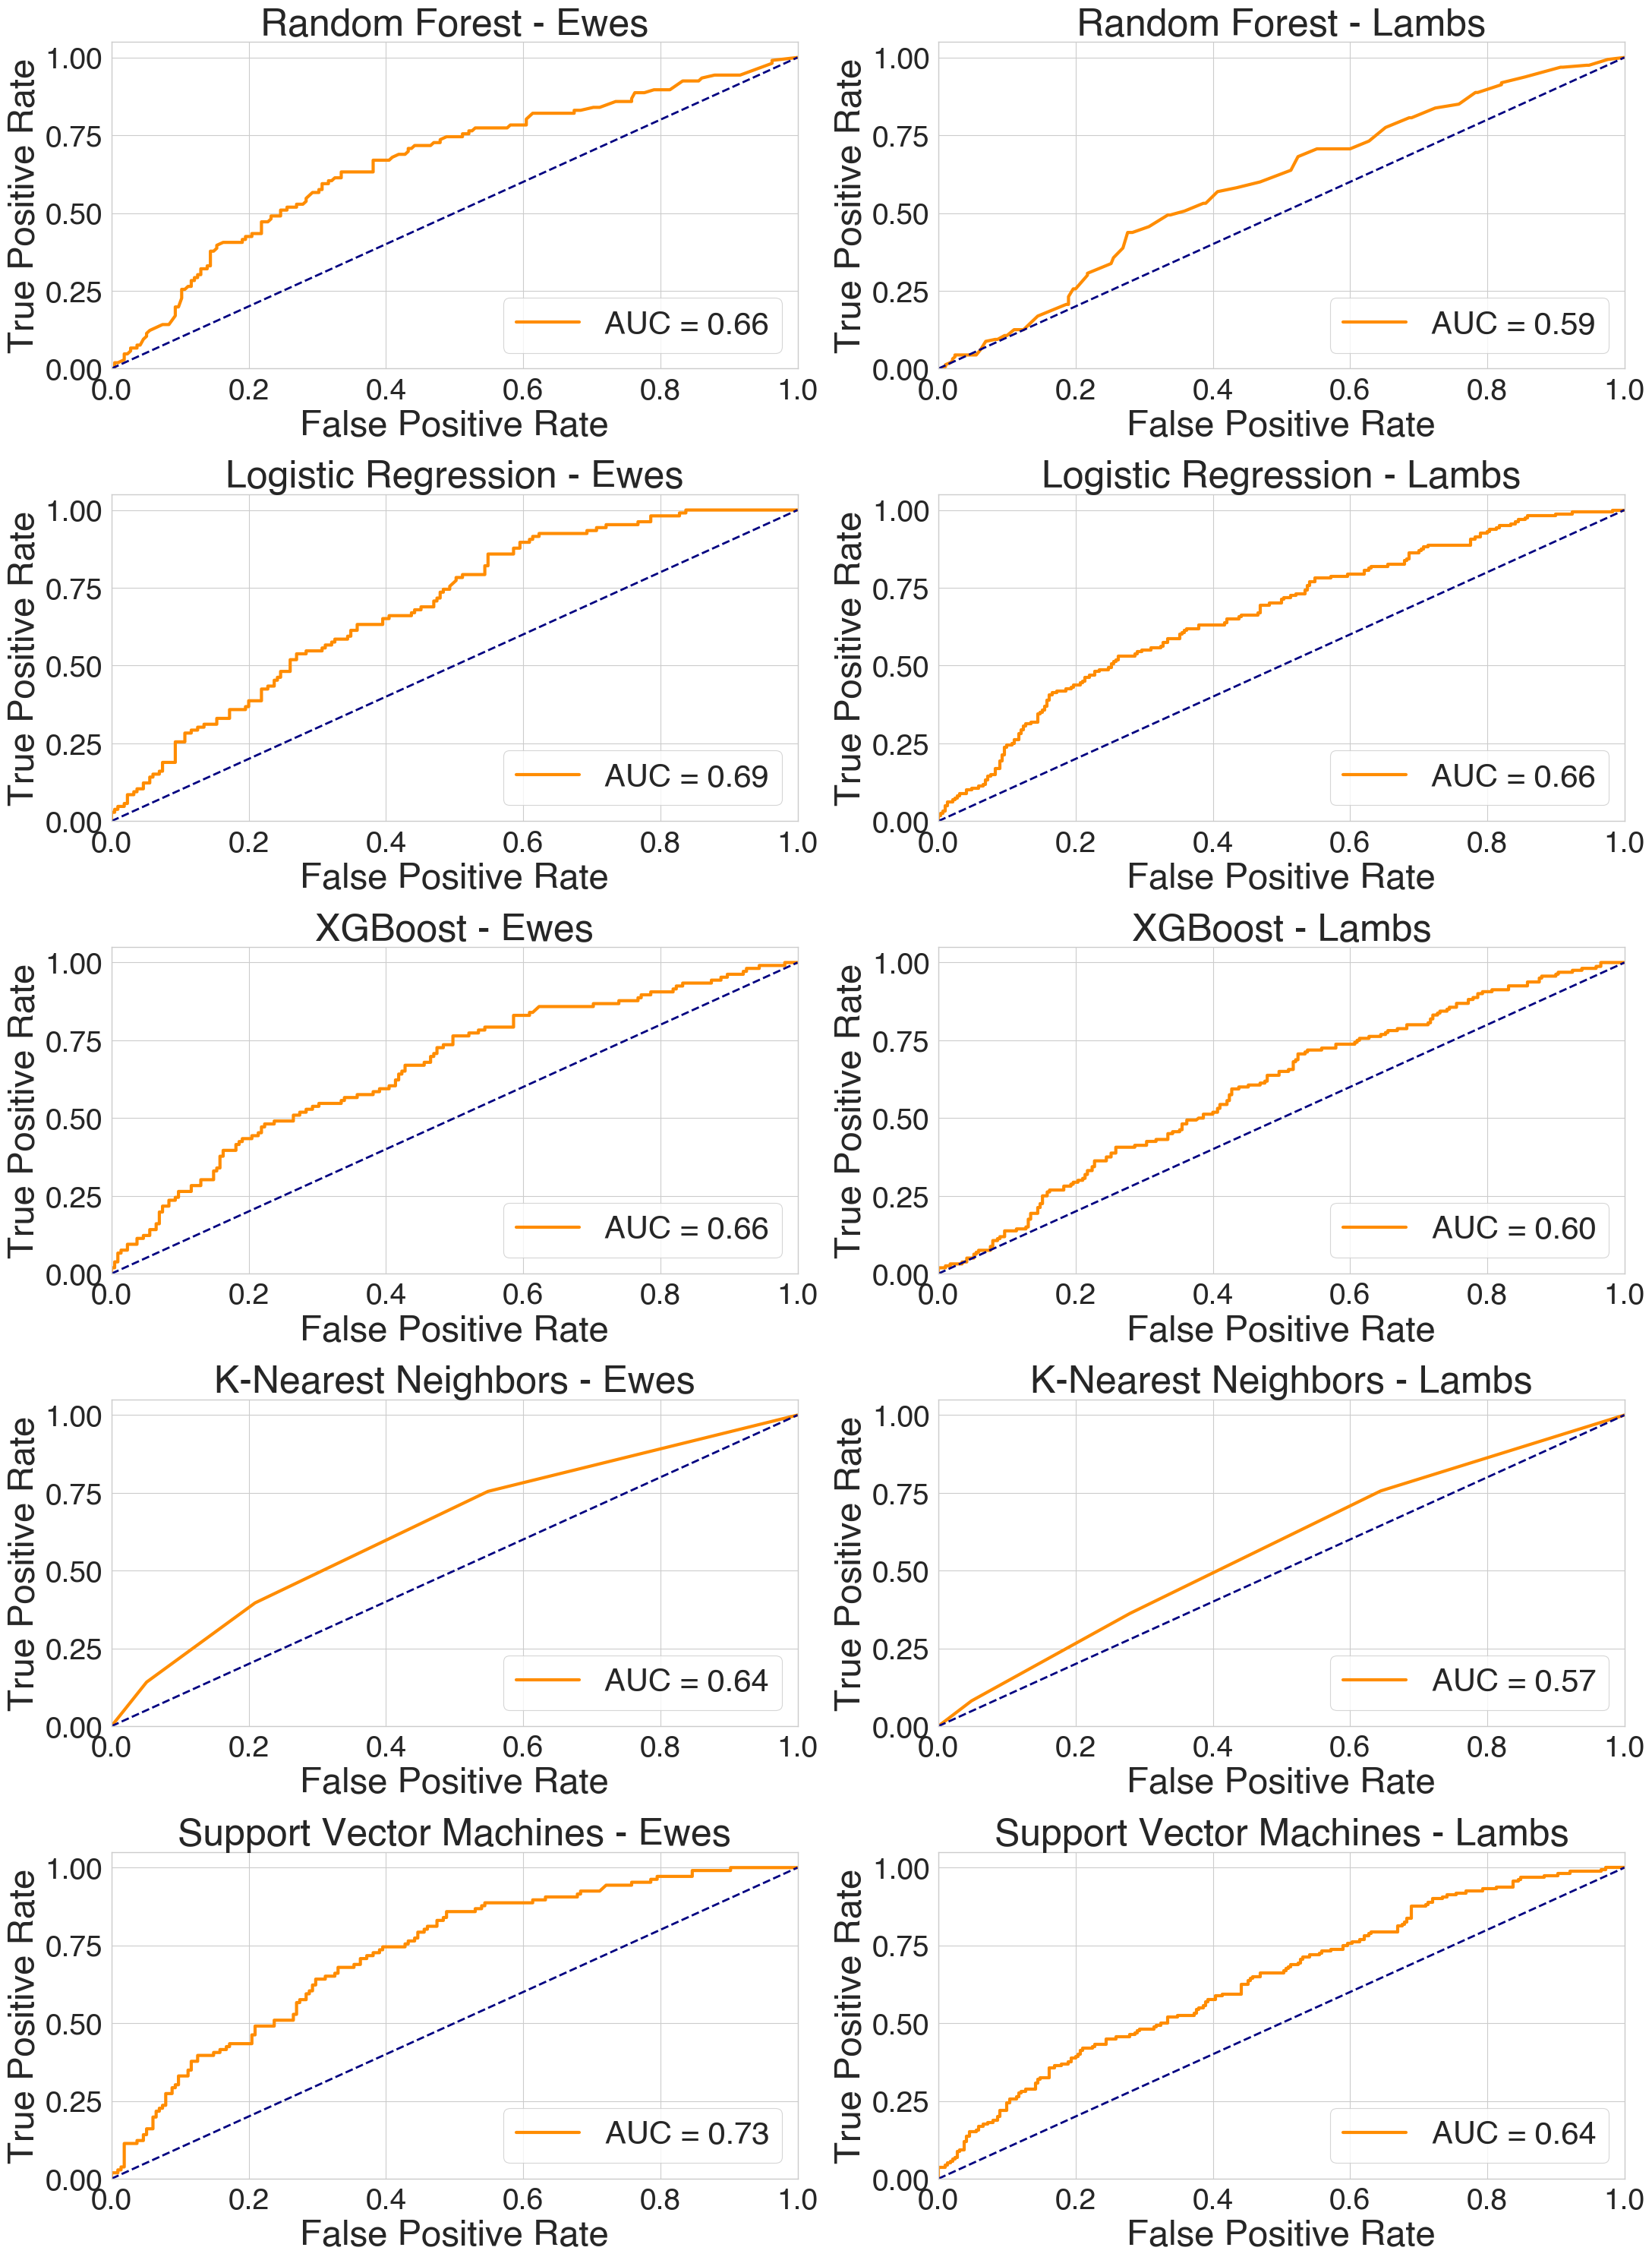

In [6]:
# Define model and display names
model_names = ['random_forest', 'logistic_regression', 'xgboost', 'knn', 'svm']
display_names = ['Random Forest', 'Logistic Regression', 'XGBoost', 'K-Nearest Neighbors', 'Support Vector Machines']

# Create a grid of subplots: one row per model, two columns (Ewes & Lambs)
fig, axes = plt.subplots(len(model_names), 2, figsize=(22, 30))

def plot_roc(ax, y_true, y_proba, title):
    # Compute and plot the ROC curve along with its AUC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, color='darkorange', lw=3, label=f'AUC = {auc(fpr, tpr):.2f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    ax.set_title(title, fontsize=36)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=34)
    ax.set_ylabel('True Positive Rate', fontsize=34)
    ax.legend(loc="lower right", fontsize=30)
    ax.tick_params(axis='both', which='major', labelsize=28)

# Loop over models and plot ROC for both datasets
for i, (mname, dname) in enumerate(zip(model_names, display_names)):
    # For SVM, enable probability estimates
    model_kw = {}
    
    # Ewes ROC
    res_e, best_model_e, X_test_e, y_test_e = test_combined_predictors(
        ewes_df, repro_predictors_ewes, 'group_binary', 
        get_model(mname, **model_kw), param_grids[mname], ret=True
    )
    plot_roc(axes[i, 0], y_test_e, best_model_e.predict_proba(X_test_e)[:, 1], f'{dname} - Ewes')
    
    # Lambs ROC
    res_l, best_model_l, X_test_l, y_test_l = test_combined_predictors(
        lambs_df, repro_predictors_lambs, 'eweseroconverted_binary', 
        get_model(mname, **model_kw), param_grids[mname], ret=True
    )
    plot_roc(axes[i, 1], y_test_l, best_model_l.predict_proba(X_test_l)[:, 1], f'{dname} - Lambs')

plt.tight_layout()
plt.savefig("/Users/davidcalleja/Desktop/THESIS/analysis/figures/ROC.png", dpi=300)
plt.show()

Optimizing AUC should guide future steps. No point in true positives >90% if false positives >60%.

## Scaling 

Combined Ewes - Predictor Performance (Random Forest)


Combined Lambs - Predictor Performance (Random Forest)


Combined Ewes - Predictor Performance (Logistic Regression)


Combined Lambs - Predictor Performance (Logistic Regression)


Combined Ewes - Predictor Performance (XGBoost)


Combined Lambs - Predictor Performance (XGBoost)


Combined Ewes - Predictor Performance (K-Nearest Neighbors)


Combined Lambs - Predictor Performance (K-Nearest Neighbors)


Combined Ewes - Predictor Performance (Support Vector Machines)


Combined Lambs - Predictor Performance (Support Vector Machines)


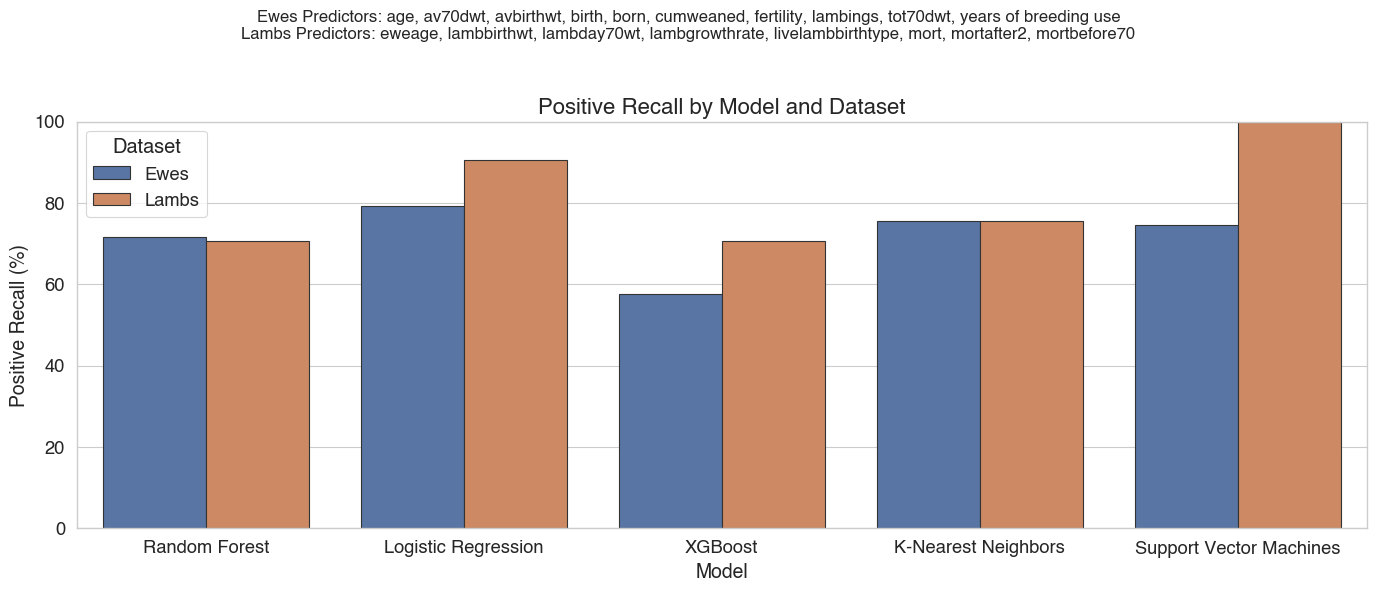

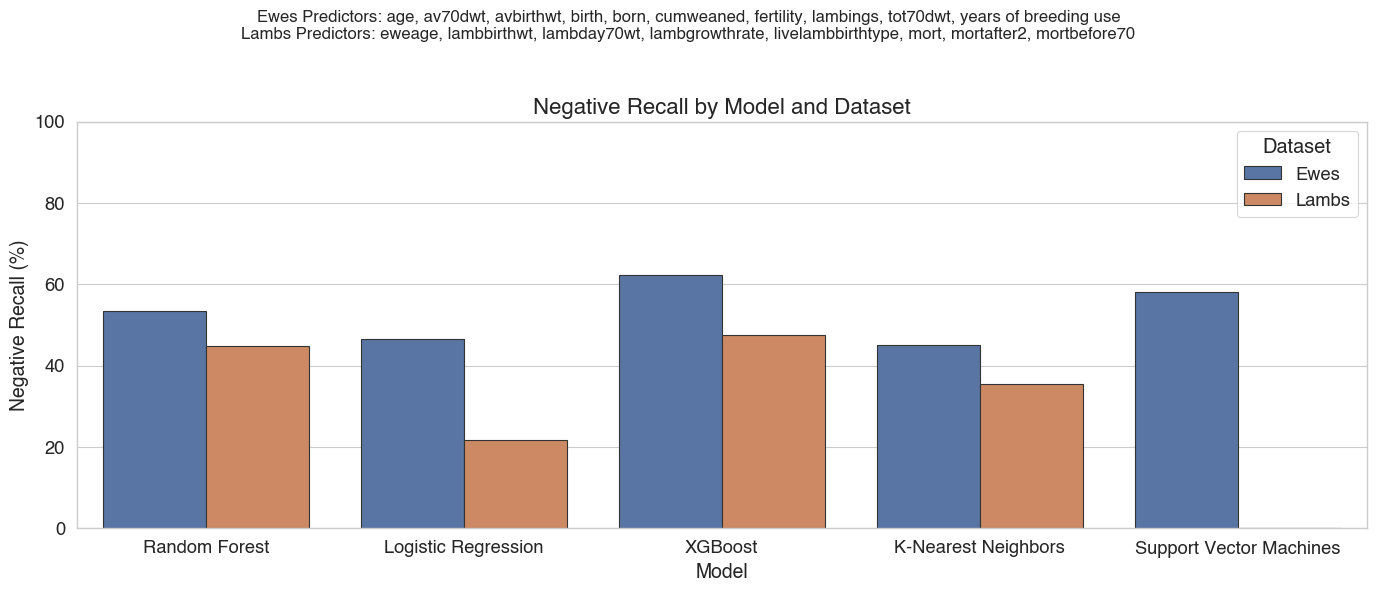

In [33]:
# --- Preprocessing Function ---
def preprocess_data(df, drop_col, target=None, recode_map=None):
    df = df.drop(columns=[drop_col], errors='ignore')
    if target and recode_map:
        df = df.dropna(subset=[target]).copy()
        df[target + '_binary'] = df[target].map(recode_map)
    return df

# Run preprocessing
ewes_df = preprocess_data(ewes_df, 'Unnamed: 0', 'group', {'minus': 0, 'plus': 1})
lambs_df = preprocess_data(lambs_df, 'Unnamed: 0', 'eweseroconverted', {'never': 0, 'before': 1, 'during': 1})

# --- Model Factory ---
def get_model(model_name, **kwargs):
    name = model_name.lower()
    if name == 'svm':
        kwargs.pop('probability', None)
        return SVC(random_state=42, probability=True, **kwargs)
    elif name == 'random_forest':
        return RandomForestClassifier(random_state=42)
    elif name == 'logistic_regression':
        return LogisticRegression(random_state=42, max_iter=1000)
    elif name == 'xgboost':
        return XGBClassifier(random_state=42, eval_metric='logloss')
    elif name == 'knn':
        return KNeighborsClassifier(n_neighbors=5)
    else:
        return None

    # Wrap with a pipeline if scaling is enabled and the model is sensitive to feature scale.
    if scale_features and name in ['svm', 'logistic_regression', 'knn']:
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', base_model)
        ])
    else:
        return base_model

# --- Testing Function ---
def test_combined_predictors(df, predictors, target, model, param_grid=None, return_test_data=False):
    # Drop rows with missing predictors or target
    d = df.dropna(subset=predictors + [target]).copy()
    for col in predictors:
        if d[col].dtype == 'object':
            d[col] = d[col].astype('category').cat.codes
    X_train, X_test, y_train, y_test = train_test_split(
        d[predictors], d[target], test_size=0.2, random_state=42, stratify=d[target]
    )
    

    if param_grid:
        scorer = make_scorer(recall_score, pos_label=1)
        grid = GridSearchCV(model, param_grid, cv=10, scoring= scorer, n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model, best_params = grid.best_estimator_, grid.best_params_
    else:
        model.fit(X_train, y_train)
        best_model, best_params = model, "N/A"
        
    # Get probabilities and apply threshold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    threshold = 0.25
    y_pred = (y_proba > threshold).astype(int)
    
    # Compute metrics
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)
    rec_neg = (cm[0, 0] / cm[0].sum() * 100) if cm[0].sum() else 0
    rec_pos = (cm[1, 1] / cm[1].sum() * 100) if cm[1].sum() else 0
    result_df = pd.DataFrame([[", ".join(predictors), len(d), acc, rec_neg, rec_pos, best_params]],
                             columns=["Predictors", "Sample Size", "Accuracy (%)", 
                                      "Recall for Negative (0) (%)", "Recall for Positive (1) (%)", "Best Params"])
    
    if return_test_data:
        return result_df, best_model, X_test, y_test
    else:
        return result_df

# --- Run Model Tests for Both Datasets ---
def run_model_test_combined(model_name, display_name, preds_ewes, preds_lambs, param_grid=None, **kwargs):
    model = get_model(model_name, **kwargs)
    e_res = test_combined_predictors(ewes_df, preds_ewes, 'group_binary', model, param_grid)
    l_res = test_combined_predictors(lambs_df, preds_lambs, 'eweseroconverted_binary', model, param_grid)
    
    # Add Dataset column
    e_res['Dataset'] = 'Ewes'
    l_res['Dataset'] = 'Lambs'
    
    comb = pd.concat([e_res, l_res], ignore_index=True)
    comb['Model'] = display_name
    comb['Accuracy (%)'] = comb['Accuracy (%)'].map("{:.2f}%".format)
    
    tools.display_dataframe_to_user(name=f"Combined Ewes - Predictor Performance ({display_name})", dataframe=e_res)
    tools.display_dataframe_to_user(name=f"Combined Lambs - Predictor Performance ({display_name})", dataframe=l_res)
    
    return comb

# --- Parameter Grids & Predictors ---
param_grids = {
    'random_forest': {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]},
    'logistic_regression': {'C': [0.1, 1, 10], 'solver': ['liblinear']},
    'xgboost': {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]},
    'knn': {'n_neighbors': [3, 5, 7]},
    'svm': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}

repro_predictors_ewes = ['age', 'av70dwt', 'avbirthwt', 'birth', 'born', 'cumweaned', 'fertility', 'lambings', 'tot70dwt', 'years of breeding use']
repro_predictors_lambs = ['eweage', 'lambbirthwt', 'lambday70wt', 'lambgrowthrate', 'livelambbirthtype', 'mort', 'mortafter2', 'mortbefore70']

# Run tests for each model and collect results
combined_results_rf = run_model_test_combined('random_forest', 'Random Forest', repro_predictors_ewes, repro_predictors_lambs, param_grids['random_forest'])
combined_results_lr = run_model_test_combined('logistic_regression', 'Logistic Regression', repro_predictors_ewes, repro_predictors_lambs, param_grids['logistic_regression'])
combined_results_xgb = run_model_test_combined('xgboost', 'XGBoost', repro_predictors_ewes, repro_predictors_lambs, param_grids['xgboost'])
combined_results_knn = run_model_test_combined('knn', 'K-Nearest Neighbors', repro_predictors_ewes, repro_predictors_lambs, param_grids['knn'])
combined_results_svm = run_model_test_combined('svm', 'Support Vector Machines', repro_predictors_ewes, repro_predictors_lambs, param_grids['svm'])

# Combine all model results into one DataFrame for plotting
combined_repro_df = pd.concat([combined_results_rf, combined_results_lr, combined_results_xgb, combined_results_knn, combined_results_svm], ignore_index=True)


# Define suptitle text
predictors_text = (
    f"Ewes Predictors: {', '.join(sorted(repro_predictors_ewes))}\n"
    f"Lambs Predictors: {', '.join(sorted(repro_predictors_lambs))}"
)

# --- Positive Recall Plot ---
sns.set_theme(style="whitegrid", context="paper", font="Helvetica", font_scale=1.5)
plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Recall for Positive (1) (%)', hue='Dataset', data=combined_repro_df,
            palette="deep", edgecolor=".2", err_kws={'linewidth': 1.5})
plt.xlabel("Model", fontsize=14)
plt.ylabel("Positive Recall (%)", fontsize=14)
plt.title("Positive Recall by Model and Dataset", fontsize=16, weight='bold')
plt.ylim(0, 100)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.suptitle(predictors_text, fontsize=12, y=0.99)
plt.savefig("/Users/davidcalleja/Desktop/THESIS/analysis/figures/Positive_Recall_NewPredictors_scaled.png", dpi=300)
plt.show()

# --- Negative Recall Plot ---
plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Recall for Negative (0) (%)', hue='Dataset', data=combined_repro_df,
            palette="deep", edgecolor=".2", err_kws={'linewidth': 1.5})
plt.xlabel("Model", fontsize=14)
plt.ylabel("Negative Recall (%)", fontsize=14)
plt.title("Negative Recall by Model and Dataset", fontsize=16, weight='bold')
plt.ylim(0, 100)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.suptitle(predictors_text, fontsize=12, y=0.99)
plt.savefig("/Users/davidcalleja/Desktop/THESIS/analysis/figures/Negative_Recall_NewPredictors_scaled.png", dpi=300)
plt.show()


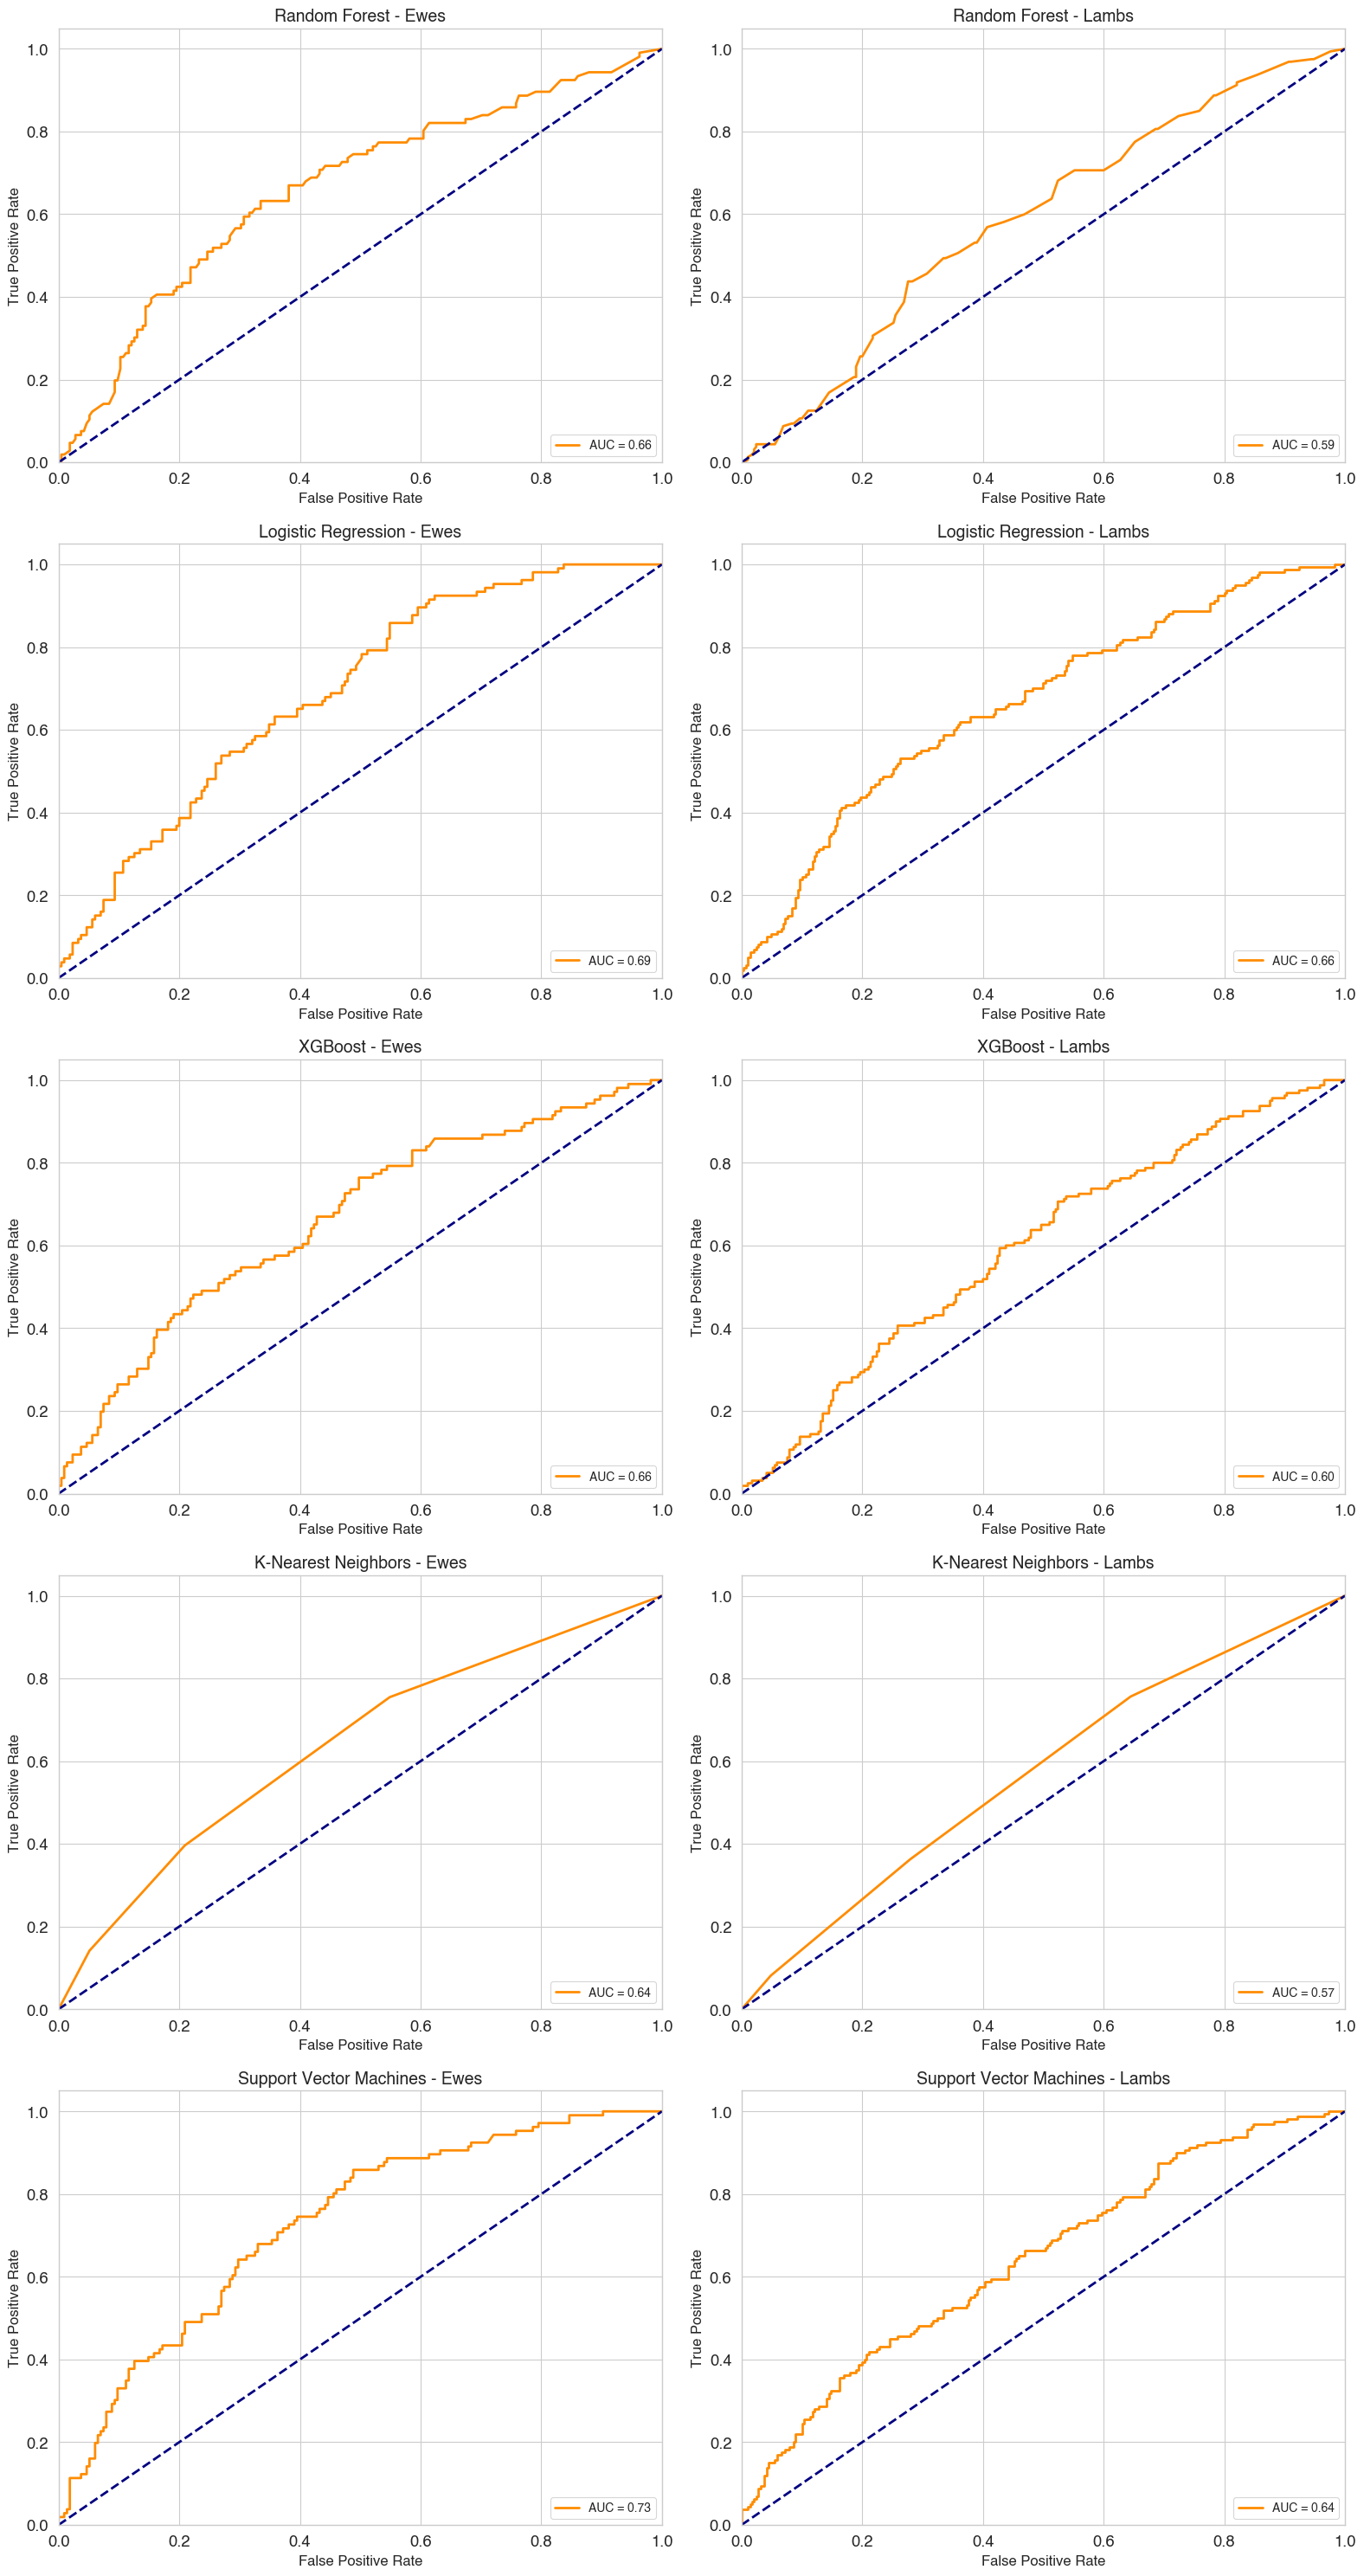

In [35]:
# List of model names and display names
model_names = ['random_forest', 'logistic_regression', 'xgboost', 'knn', 'svm']
display_names = ['Random Forest', 'Logistic Regression', 'XGBoost', 'K-Nearest Neighbors', 'Support Vector Machines']

# Create a grid of subplots: 5 rows (models) x 2 columns (Ewes and Lambs)
fig, axes = plt.subplots(nrows=len(model_names), ncols=2, figsize=(16, 30))

for i, (mname, dname) in enumerate(zip(model_names, display_names)):
    model_kw = {'probability': True} if mname.lower() == 'svm' else {}
    res_e, best_model_e, X_test_e, y_test_e = test_combined_predictors(
        ewes_df,
        repro_predictors_ewes,
        'group_binary',
        get_model(mname, **model_kw),
        param_grids[mname],
        return_test_data=True
    )
    # Compute ROC for ewes:
    y_proba_e = best_model_e.predict_proba(X_test_e)[:, 1]
    fpr_e, tpr_e, _ = roc_curve(y_test_e, y_proba_e)
    roc_auc_e = auc(fpr_e, tpr_e)
    
    ax_e = axes[i, 0]
    ax_e.plot(fpr_e, tpr_e, color='darkorange', lw=2, label=f'AUC = {roc_auc_e:.2f}')
    ax_e.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_e.set_title(f'{dname} - Ewes', fontsize=14)
    ax_e.set_xlim([0.0, 1.0])
    ax_e.set_ylim([0.0, 1.05])
    ax_e.set_xlabel('False Positive Rate', fontsize=12)
    ax_e.set_ylabel('True Positive Rate', fontsize=12)
    ax_e.legend(loc="lower right", fontsize=10)
    
    # --- Lambs ROC ---
    res_l, best_model_l, X_test_l, y_test_l = test_combined_predictors(
        lambs_df,
        repro_predictors_lambs,
        'eweseroconverted_binary',

        get_model(mname, **model_kw),
        param_grids[mname],
        return_test_data=True
    )
    # Compute ROC for lambs:
    y_proba_l = best_model_l.predict_proba(X_test_l)[:, 1]
    fpr_l, tpr_l, _ = roc_curve(y_test_l, y_proba_l)
    roc_auc_l = auc(fpr_l, tpr_l)
    
    ax_l = axes[i, 1]
    ax_l.plot(fpr_l, tpr_l, color='darkorange', lw=2, label=f'AUC = {roc_auc_l:.2f}')
    ax_l.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_l.set_title(f'{dname} - Lambs', fontsize=14)
    ax_l.set_xlim([0.0, 1.0])
    ax_l.set_ylim([0.0, 1.05])
    ax_l.set_xlabel('False Positive Rate', fontsize=12)
    ax_l.set_ylabel('True Positive Rate', fontsize=12)

    ax_l.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("/Users/davidcalleja/Desktop/THESIS/analysis/figures/ROC_scaled.png", dpi=300)
plt.show()

Results: scaling seems pretty much useless. 

## Hyperparameter tuning (RandomizedSearchCV and BayesSearchCV)

Attempt to use other hyperparameter tuning methods: run previous model on them and plot ROC curves. Yields very similar results. 

In [36]:
# Preprocess both datasets
ewes_df = preprocess_data(ewes_df, 'Unnamed: 0', 'group', {'minus': 0, 'plus': 1})
lambs_df = preprocess_data(lambs_df, 'Unnamed: 0', 'eweseroconverted', {'never': 0, 'before': 1, 'during': 1})

# --- Model Factory Function ---
def get_model(name, **kw):
    # Return a model instance based on the provided name
    n = name.lower()
    models = {
        'random_forest': lambda: RandomForestClassifier(random_state=42),
        'logistic_regression': lambda: LogisticRegression(random_state=42, max_iter=1000),
        'xgboost': lambda: XGBClassifier(random_state=42, eval_metric='logloss'),
        'knn': lambda: KNeighborsClassifier(n_neighbors=5),
        'svm': lambda: SVC(random_state=42, probability=True, **{k: v for k, v in kw.items() if k != 'probability'})
    }
    return models.get(n, lambda: None)()

# --- Tuning & Testing Function for Combined Predictors ---
def test_combined_predictors(df, preds, target, model, param_space=None, tuner='random', n_iter=10, ret=False):
    """
    Tuner can be 'random' or 'bayesian'. If param_space is provided, we perform tuning.
    The scoring used here is AUC ('roc_auc').
    """
    # Clean data, encode categoricals, and split data
    d = df.dropna(subset=preds + [target]).copy()
    for col in preds:
        if d[col].dtype == 'object':
            d[col] = d[col].astype('category').cat.codes
    X_tr, X_te, y_tr, y_te = train_test_split(d[preds], d[target], test_size=0.2, random_state=42, stratify=d[target])
    
    if param_space:
        scoring = 'roc_auc'
        if tuner == 'random':
            searcher = RandomizedSearchCV(model, param_space, n_iter=n_iter, cv=10,
                                          scoring=scoring, n_jobs=-1, random_state=42)
        elif tuner == 'bayesian':
            searcher = BayesSearchCV(model, param_space, n_iter=n_iter, cv=10,
                                     scoring=scoring, n_jobs=-1, random_state=42)
        else:
            raise ValueError("Tuner must be 'random' or 'bayesian'")
        searcher.fit(X_tr, y_tr)
        best_model = searcher.best_estimator_
        best_params = searcher.best_params_
    else:
        model.fit(X_tr, y_tr)
        best_model, best_params = model, "N/A"
    
    # Compute AUC on test data
    y_pred_proba = best_model.predict_proba(X_te)[:, 1]
    auc_val = roc_auc_score(y_te, y_pred_proba)
    
    # Return results as a DataFrame row
    res = pd.DataFrame([[", ".join(preds), len(d), auc_val, best_params]],
                       columns=["Predictors", "Sample Size", "AUC", "Best Params"])
    if ret:
        return res, best_model, X_te, y_te
    else:
        return res

# --- Combined Model Test Function ---
def run_model_test_combined(model_name, display_name, p_ewes, p_lambs, param_space=None, tuner='random', n_iter=10, **kw):
    mdl = get_model(model_name, **kw)
    # Test on Ewes
    e_res = test_combined_predictors(ewes_df, p_ewes, 'group_binary', mdl, param_space, tuner=tuner, n_iter=n_iter)
    e_res['Dataset'] = 'Ewes'
    # Test on Lambs
    l_res = test_combined_predictors(lambs_df, p_lambs, 'eweseroconverted_binary', mdl, param_space, tuner=tuner, n_iter=n_iter)
    l_res['Dataset'] = 'Lambs'
    
    comb = pd.concat([e_res, l_res], ignore_index=True)
    comb['Model'] = display_name
    comb['Tuner'] = tuner.capitalize()
    return comb

# --- Define Parameter Spaces for Random Search (using scipy.stats distributions) ---
param_distributions = {
    'random_forest': {
        'n_estimators': randint(50, 500),
        'max_depth': randint(3, 100)
    },
    'logistic_regression': {
        'C': uniform(0.1, 20),
        'solver': ['liblinear']  # fixed choice
    },
    'xgboost': {
        'max_depth': randint(3, 100),
        'learning_rate': uniform(0.01, 0.9),
        'n_estimators': randint(50, 1000)
    },
    'knn': {
        'n_neighbors': randint(1, 100)
    },
    'svm': {
        'C': uniform(0.1, 20),
        'kernel': ['linear', 'rbf', 'poly']
    }
}

# --- Define Parameter Spaces for Bayesian Optimization (using skopt spaces) ---
param_ranges = {
    'random_forest': {
        'n_estimators': Integer(50, 500),
        'max_depth': Integer(3, 100)
    },
    'logistic_regression': {
        'C': Real(0.1, 20, prior='log-uniform'),
        'solver': Categorical(['liblinear'])
    },
    'xgboost': {
        'max_depth': Integer(3, 100),
        'learning_rate': Real(0.01, 0.9, prior='log-uniform'),
        'n_estimators': Integer(50, 1000)
    },
    'knn': {
        'n_neighbors': Integer(1, 100)
    },
    'svm': {
        'C': Real(0.1, 40, prior='log-uniform'),
        'kernel': Categorical(['linear', 'rbf', 'poly'])
    }
}

# --- Predictor Definitions ---
repro_predictors_ewes = ['age', 'av70dwt', 'avbirthwt', 'birth', 'born',
                           'cumweaned', 'fertility', 'lambings', 'tot70dwt', 'years of breeding use']
repro_predictors_lambs = ['eweage', 'lambbirthwt', 'lambday70wt', 'lambgrowthrate',
                          'livelambbirthtype', 'mort', 'mortafter2', 'mortbefore70']

# --- Run Model Tests for Each Model and Each Tuning Method ---
# We'll loop over models and tuners (random and bayesian) to compute AUC for each dataset.
model_names = ['random_forest', 'logistic_regression', 'xgboost', 'knn', 'svm']
display_names = ['Random Forest', 'Logistic Regression', 'XGBoost', 'K-Nearest Neighbors', 'Support Vector Machines']

results = []
tuner_methods = ['random', 'bayesian']

for tuner in tuner_methods:
    for mname, dname in zip(model_names, display_names):
        # Choose the appropriate parameter space for the current tuner
        if tuner == 'random':
            param_space = param_distributions[mname]
        else:
            param_space = param_ranges[mname]
        
        res = run_model_test_combined(mname, dname, repro_predictors_ewes, repro_predictors_lambs,
                                      param_space=param_space, tuner=tuner, n_iter=10)
        results.append(res)

# Combine results into one DataFrame and pivot to show AUCs by Model, Dataset, and Tuner
combined_results = pd.concat(results, ignore_index=True)
pivot_table = combined_results.pivot_table(index=['Model', 'Dataset'], columns='Tuner', values='AUC')
print(pivot_table)

# Optionally, display the table using your tools.display_dataframe_to_user function
tools.display_dataframe_to_user(name="AUC Comparison (Random Search vs Bayesian)", dataframe=pivot_table)


Tuner                            Bayesian    Random
Model                   Dataset                    
K-Nearest Neighbors     Ewes     0.711299  0.710487
                        Lambs    0.643696  0.647489
Logistic Regression     Ewes     0.691093  0.691575
                        Lambs    0.664806  0.664828
Random Forest           Ewes     0.714480  0.711365
                        Lambs    0.657015  0.664989
Support Vector Machines Ewes     0.731066  0.732317
                        Lambs    0.337866  0.337672
XGBoost                 Ewes     0.675208  0.688416
                        Lambs    0.582554  0.619634
AUC Comparison (Random Search vs Bayesian)


## Feature engineering

In some prelim testing, seems that removing some variables does not affect ROC curve, lets put this to test. Even if tool is not very good at predicting, it might be better if it requires less input. Decided to create new variable birth_to_weaning ratio to see if AUC improved.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller th

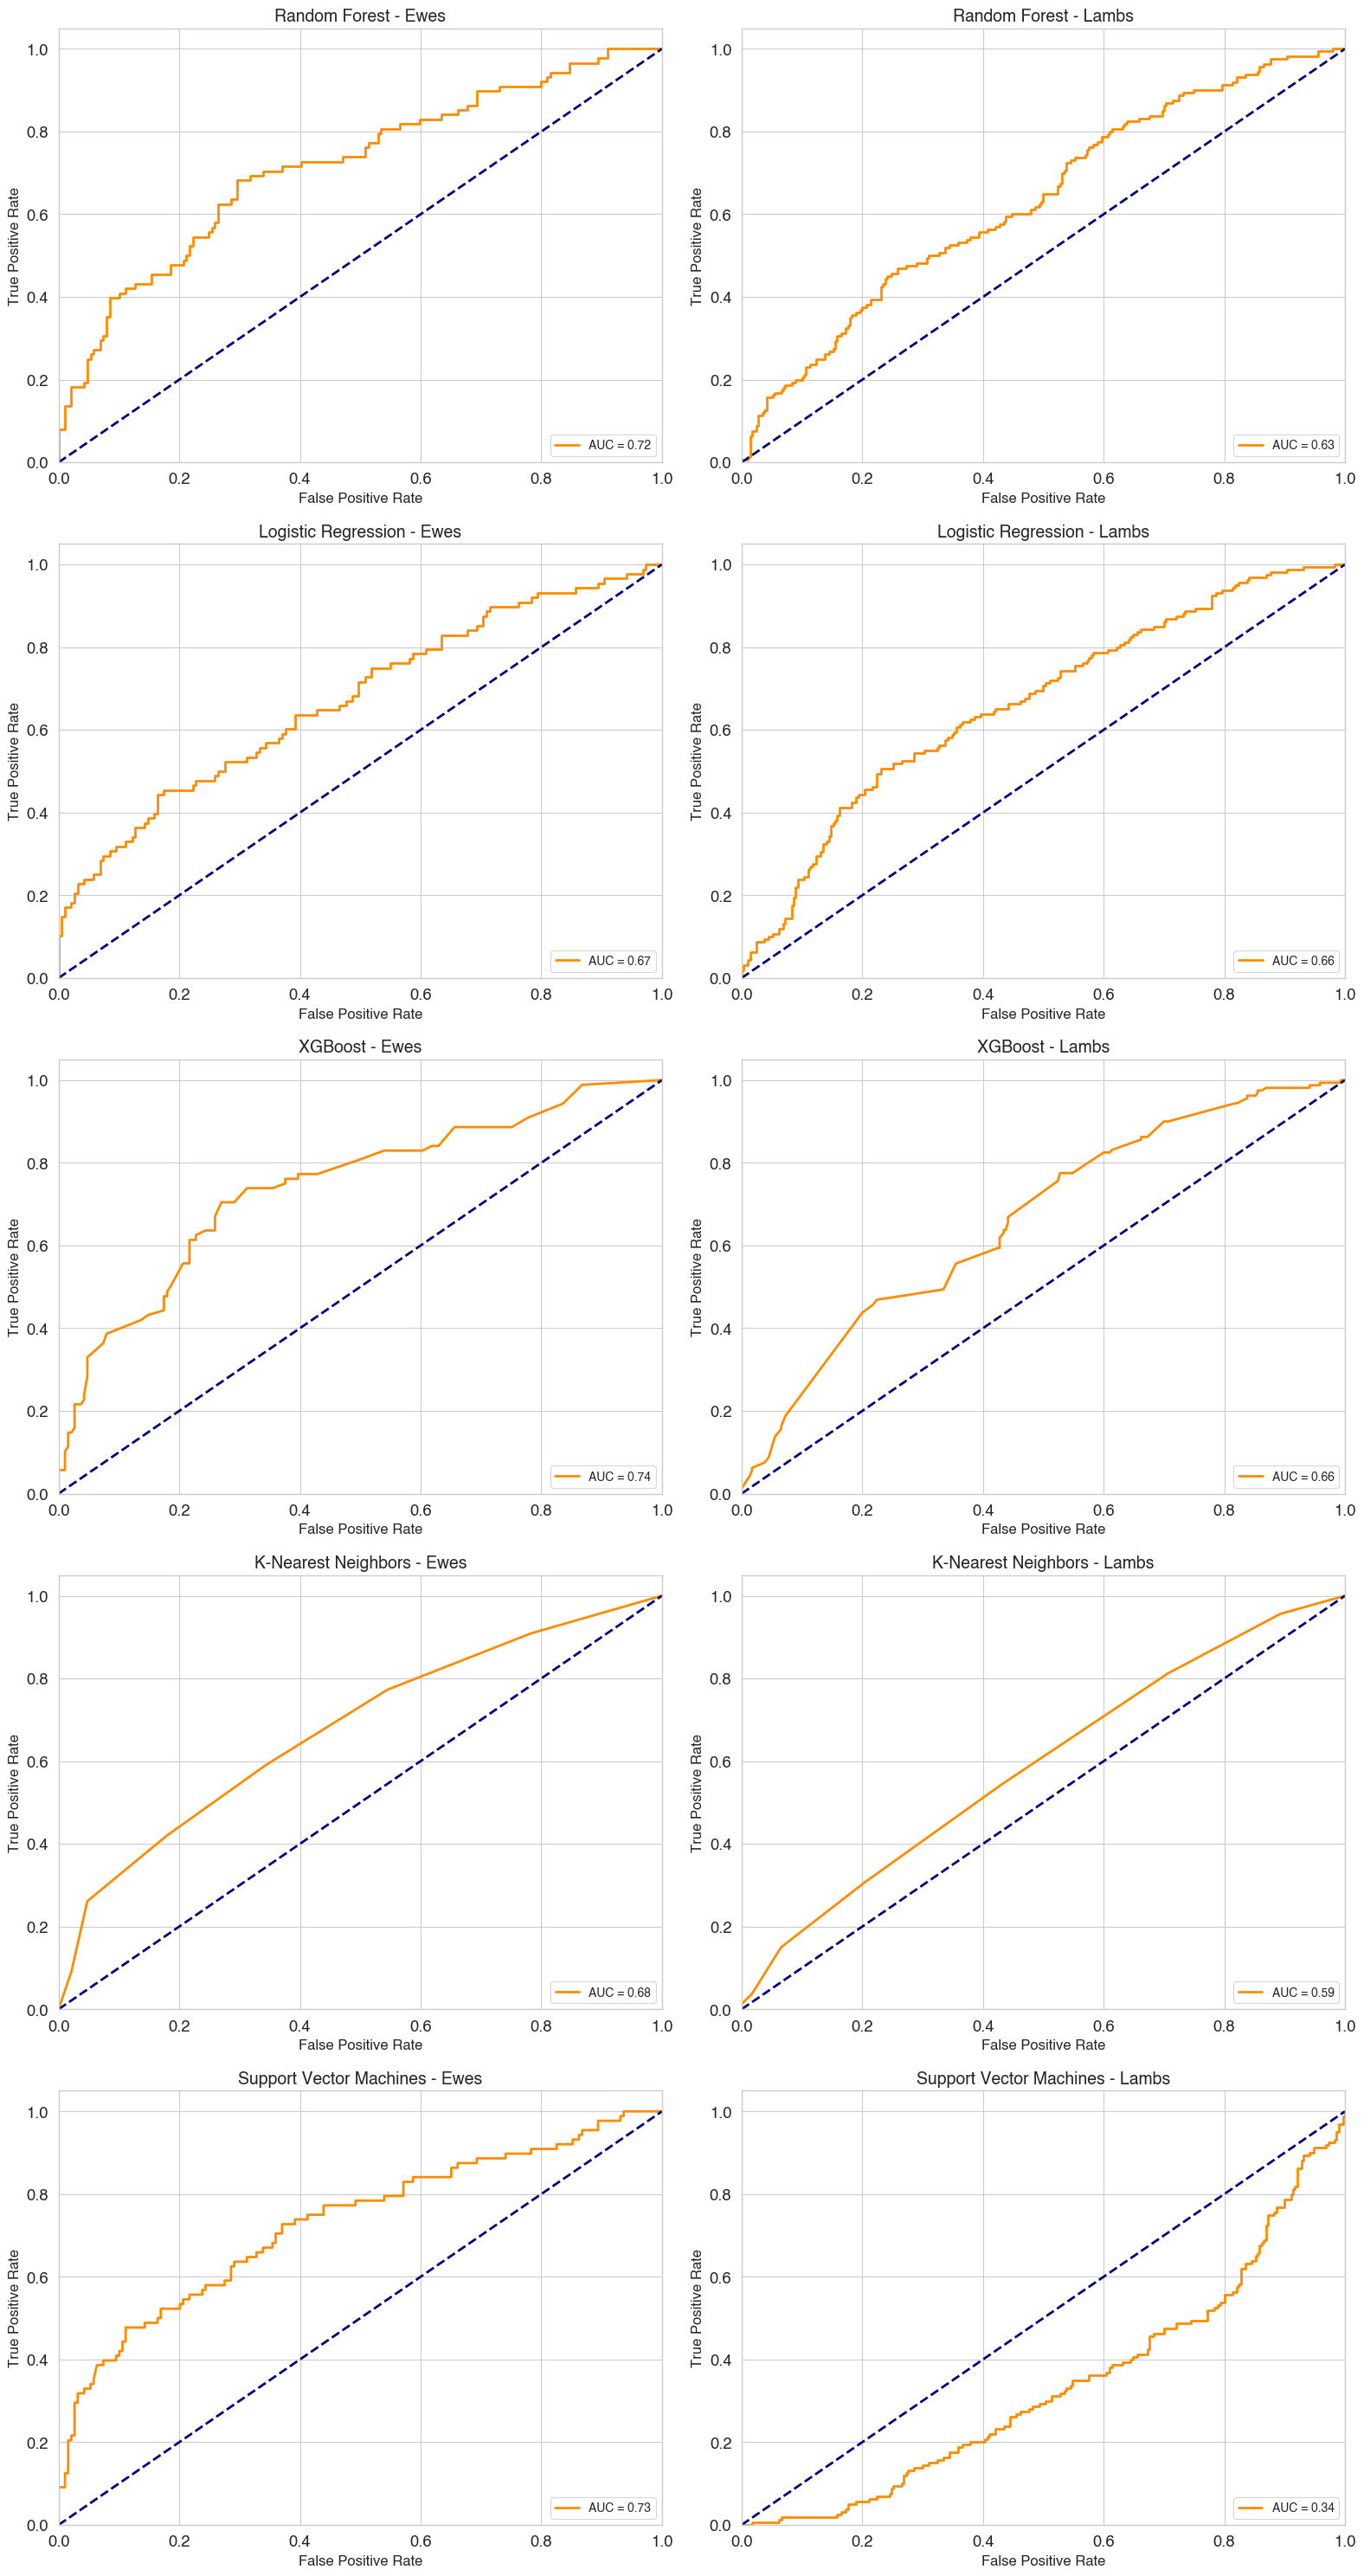

In [37]:
def add_weaning_features(df):
    df = df.copy()
    df['birth_to_weaning_ratio'] = df['avbirthwt'].replace(0, np.nan) / df['av70dwt'].replace(0, np.nan)
    return df

ewes_df = add_weaning_features(ewes_df)

repro_predictors_ewes = ['birth_to_weaning_ratio', 'age', 'av70dwt', 'avbirthwt', 'birth', 'born',
                           'cumweaned', 'fertility', 'lambings', 'tot70dwt', 'years of breeding use']
repro_predictors_lambs = ['eweage', 'lambbirthwt', 'lambday70wt', 'lambgrowthrate',
                          'livelambbirthtype', 'mort', 'mortafter2', 'mortbefore70']

crf = run_model_test_combined('random_forest', 'Random Forest', repro_predictors_ewes, repro_predictors_lambs, param_grids['random_forest'])
clr = run_model_test_combined('logistic_regression', 'Logistic Regression', repro_predictors_ewes, repro_predictors_lambs, param_grids['logistic_regression'])
cxgb = run_model_test_combined('xgboost', 'XGBoost', repro_predictors_ewes, repro_predictors_lambs, param_grids['xgboost'])
cknn = run_model_test_combined('knn', 'K-Nearest Neighbors', repro_predictors_ewes, repro_predictors_lambs, param_grids['knn'])
csvm = run_model_test_combined('svm', 'Support Vector Machines', repro_predictors_ewes, repro_predictors_lambs, param_grids['svm'])
combined_repro_df = pd.concat([crf, clr, cxgb, cknn, csvm], ignore_index=True)

# List of model names and display names
model_names = ['random_forest', 'logistic_regression', 'xgboost', 'knn', 'svm']
display_names = ['Random Forest', 'Logistic Regression', 'XGBoost', 'K-Nearest Neighbors', 'Support Vector Machines']

# Create a grid of subplots: 5 rows (models) x 2 columns (Ewes and Lambs)
fig, axes = plt.subplots(nrows=len(model_names), ncols=2, figsize=(16, 30))

for i, (mname, dname) in enumerate(zip(model_names, display_names)):
    model_kw = {'probability': True} if mname.lower() == 'svm' else {}
    res_e, best_model_e, X_test_e, y_test_e = test_combined_predictors(
        ewes_df,
        repro_predictors_ewes,
        'group_binary',
        get_model(mname, **model_kw),
        param_grids[mname],
        ret=True
    )
    # Compute ROC for ewes:
    y_proba_e = best_model_e.predict_proba(X_test_e)[:, 1]
    fpr_e, tpr_e, _ = roc_curve(y_test_e, y_proba_e)
    roc_auc_e = auc(fpr_e, tpr_e)
    
    ax_e = axes[i, 0]
    ax_e.plot(fpr_e, tpr_e, color='darkorange', lw=2, label=f'AUC = {roc_auc_e:.2f}')
    ax_e.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_e.set_title(f'{dname} - Ewes', fontsize=14)
    ax_e.set_xlim([0.0, 1.0])
    ax_e.set_ylim([0.0, 1.05])
    ax_e.set_xlabel('False Positive Rate', fontsize=12)
    ax_e.set_ylabel('True Positive Rate', fontsize=12)
    ax_e.legend(loc="lower right", fontsize=10)
    
    # --- Lambs ROC ---
    res_l, best_model_l, X_test_l, y_test_l = test_combined_predictors(
        lambs_df,
        repro_predictors_lambs,
        'eweseroconverted_binary',
        get_model(mname, **model_kw),
        param_grids[mname],
        ret=True
    )
    # Compute ROC for lambs:
    y_proba_l = best_model_l.predict_proba(X_test_l)[:, 1]
    fpr_l, tpr_l, _ = roc_curve(y_test_l, y_proba_l)
    roc_auc_l = auc(fpr_l, tpr_l)

    ax_l = axes[i, 1]
    ax_l.plot(fpr_l, tpr_l, color='darkorange', lw=2, label=f'AUC = {roc_auc_l:.2f}')
    ax_l.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_l.set_title(f'{dname} - Lambs', fontsize=14)
    ax_l.set_xlim([0.0, 1.0])
    ax_l.set_ylim([0.0, 1.05])
    ax_l.set_xlabel('False Positive Rate', fontsize=12)
    ax_l.set_ylabel('True Positive Rate', fontsize=12)
    ax_l.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("/Users/davidcalleja/Desktop/THESIS/analysis/figures/ROC.png", dpi=300)
plt.show()

## Optimal variable analysis

RFECV analysis to determine which variables are most relevant. Only possible for Random Forests, LR, and XGBoost since KNN and SVM do not have a built-in way to rank features.

Figure saved to: /Users/davidcalleja/Desktop/THESIS/analysis/figures/Feature_Importance_Random Forest_Ewes.png


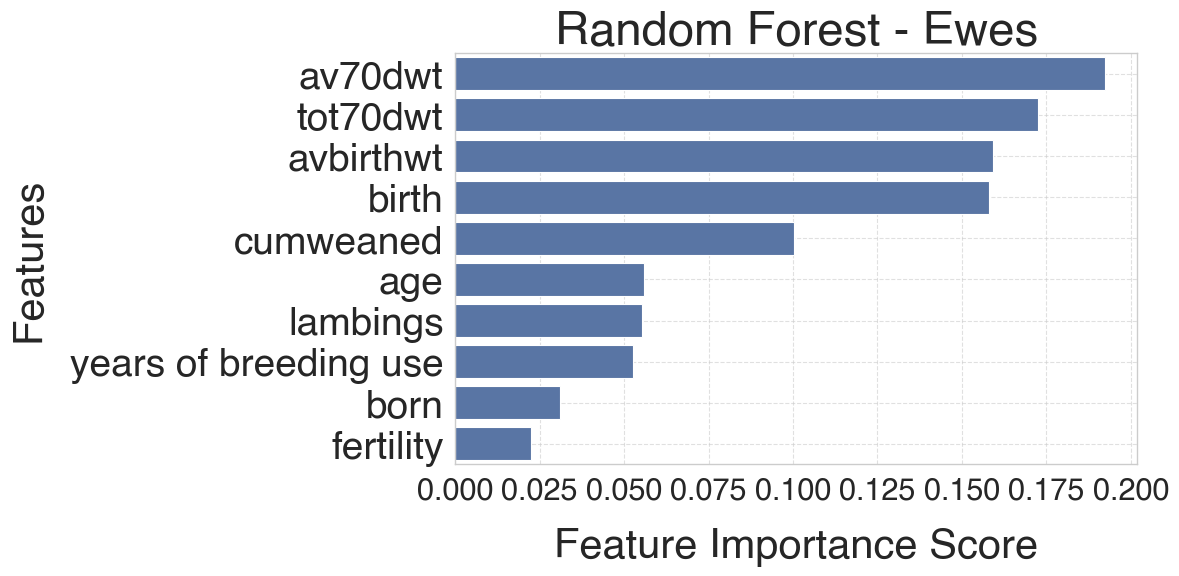

For Random Forest and Ewes dataset:['av70dwt', 'tot70dwt', 'avbirthwt', 'birth', 'cumweaned', 'age', 'lambings', 'years of breeding use', 'born', 'fertility'],[np.float64(0.19226925478201715), np.float64(0.17255905740654492), np.float64(0.1592452306812927), np.float64(0.15811426423924513), np.float64(0.10032953643293448), np.float64(0.05598707385139793), np.float64(0.05542239089420257), np.float64(0.052532798325438695), np.float64(0.031086975495909813), np.float64(0.022453417891016705)]
Figure saved to: /Users/davidcalleja/Desktop/THESIS/analysis/figures/Feature_Importance_Random Forest_Lambs.png


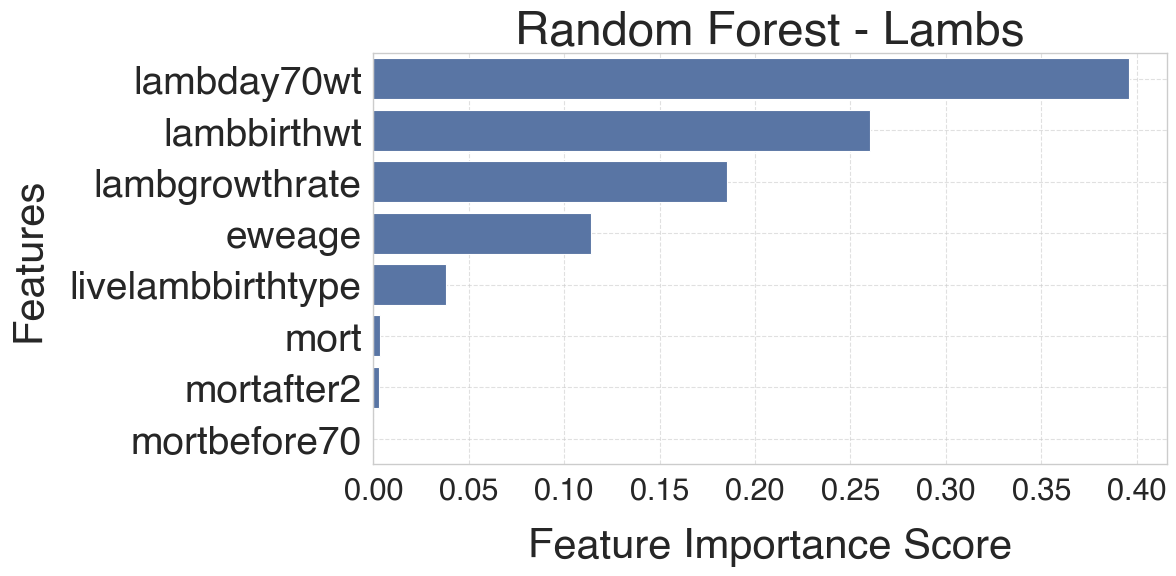

For Random Forest and Lambs dataset:['lambday70wt', 'lambbirthwt', 'lambgrowthrate', 'eweage', 'livelambbirthtype', 'mort', 'mortafter2', 'mortbefore70'],[np.float64(0.39601300533384887), np.float64(0.26029187148377236), np.float64(0.18512891174749518), np.float64(0.11393817410850396), np.float64(0.038318240750358154), np.float64(0.003260794427110014), np.float64(0.0030490021489113935), np.float64(0.0)]
Figure saved to: /Users/davidcalleja/Desktop/THESIS/analysis/figures/Feature_Importance_Logistic Regression_Ewes.png


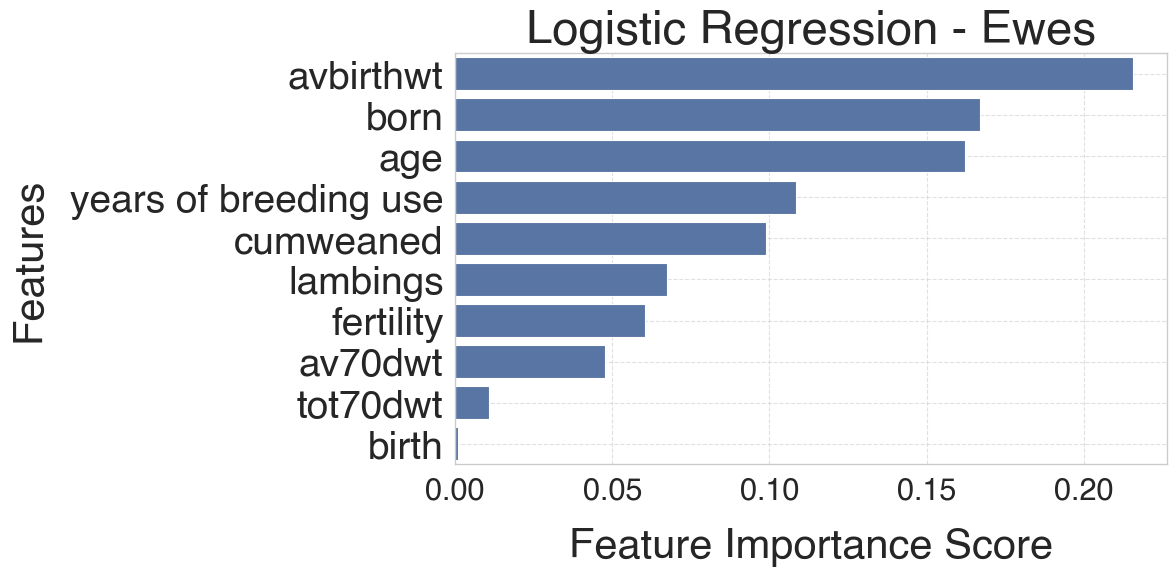

For Logistic Regression and Ewes dataset:['avbirthwt', 'born', 'age', 'years of breeding use', 'cumweaned', 'lambings', 'fertility', 'av70dwt', 'tot70dwt', 'birth'],[np.float64(0.21559573928328465), np.float64(0.16710489633937337), np.float64(0.16213072689642374), np.float64(0.10855147449928487), np.float64(0.09886160428152449), np.float64(0.06751360522888365), np.float64(0.060373099856654046), np.float64(0.04766209777454192), np.float64(0.010870160234268124), np.float64(0.0008935077188039715)]
Figure saved to: /Users/davidcalleja/Desktop/THESIS/analysis/figures/Feature_Importance_Logistic Regression_Lambs.png


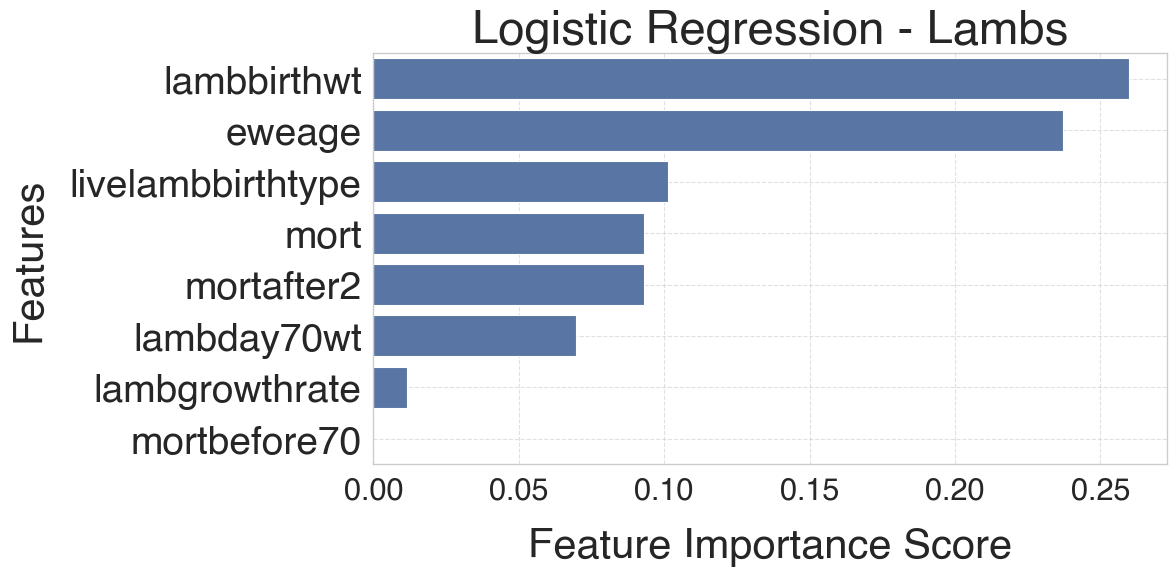

For Logistic Regression and Lambs dataset:['lambbirthwt', 'eweage', 'livelambbirthtype', 'mort', 'mortafter2', 'lambday70wt', 'lambgrowthrate', 'mortbefore70'],[np.float64(0.2598790089058681), np.float64(0.2371548835480892), np.float64(0.1013091575428315), np.float64(0.09307084909207106), np.float64(0.09307084909207106), np.float64(0.06965079800623579), np.float64(0.011433862282324361), np.float64(0.0)]
Figure saved to: /Users/davidcalleja/Desktop/THESIS/analysis/figures/Feature_Importance_XGBoost_Ewes.png


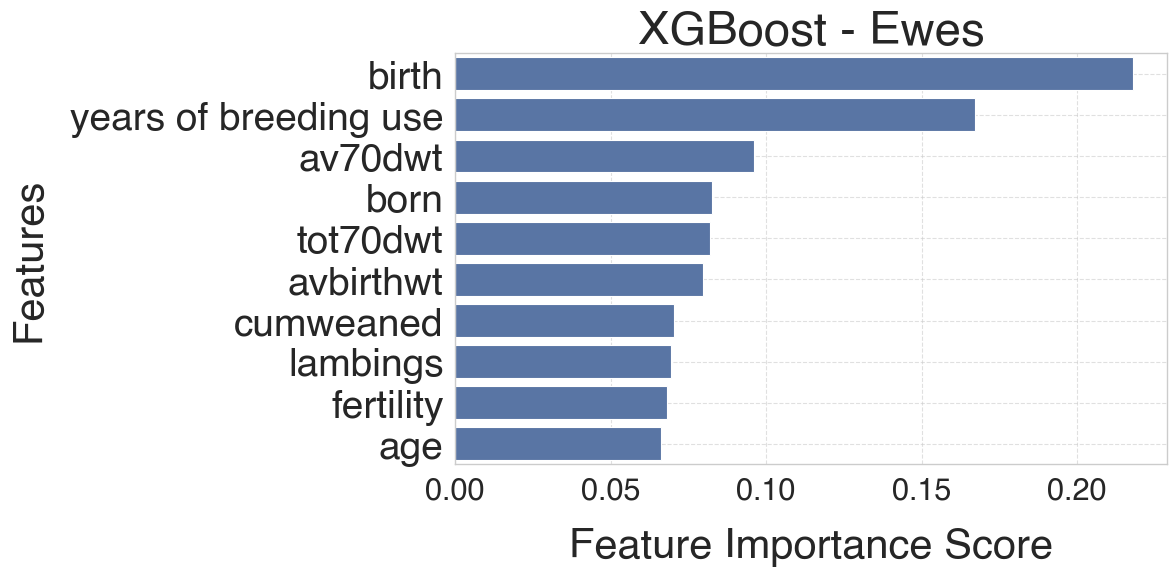

For XGBoost and Ewes dataset:['birth', 'years of breeding use', 'av70dwt', 'born', 'tot70dwt', 'avbirthwt', 'cumweaned', 'lambings', 'fertility', 'age'],[np.float32(0.21797058), np.float32(0.16732185), np.float32(0.09613065), np.float32(0.08251014), np.float32(0.082046956), np.float32(0.07976233), np.float32(0.070475064), np.float32(0.06937061), np.float32(0.0682235), np.float32(0.06618828)]
Figure saved to: /Users/davidcalleja/Desktop/THESIS/analysis/figures/Feature_Importance_XGBoost_Lambs.png


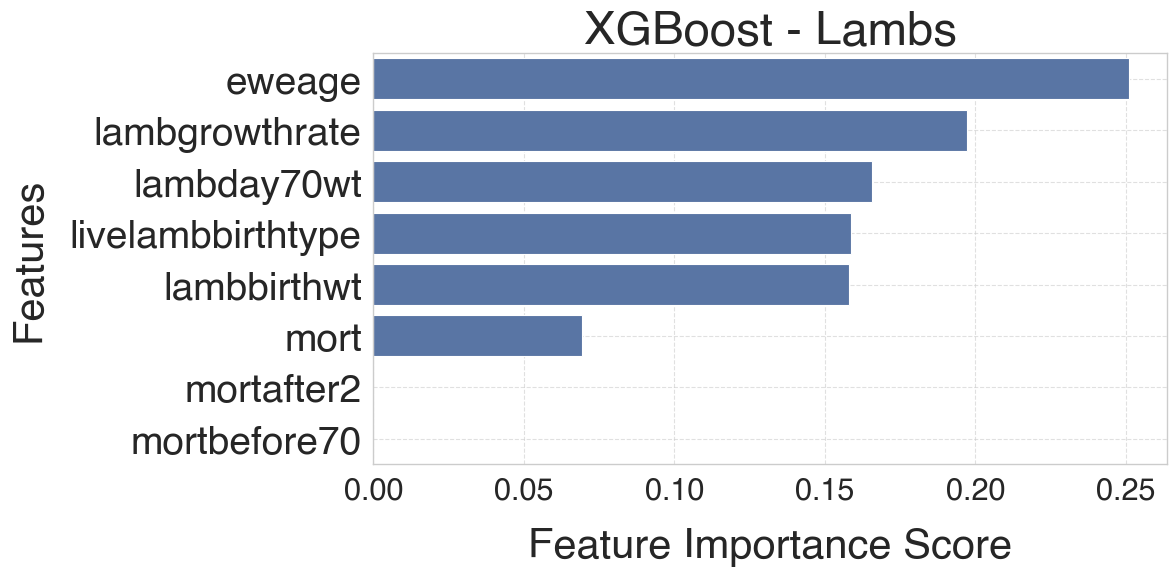

For XGBoost and Lambs dataset:['eweage', 'lambgrowthrate', 'lambday70wt', 'livelambbirthtype', 'lambbirthwt', 'mort', 'mortafter2', 'mortbefore70'],[np.float32(0.25102282), np.float32(0.19723122), np.float32(0.16577567), np.float32(0.15876402), np.float32(0.15785153), np.float32(0.069354706), np.float32(0.0), np.float32(0.0)]


In [12]:
def plot_feature_importance(model, X_test, y_test, model_name, predictors, dataset_name, save_path=None):
    """
    Plot feature importance for supported models, save the figure if a path is provided,
    and return the sorted feature names and their importance scores as a tuple of lists.
    """
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importance = np.abs(model.coef_).flatten()
    else:
        perm_imp = permutation_importance(model, X_test, y_test, scoring="accuracy", n_repeats=10, random_state=42)
        importance = perm_imp.importances_mean

    # Combine predictors and importance scores, then sort by importance (descending)
    feature_importance = sorted(zip(predictors, importance), key=lambda x: x[1], reverse=True)
    features, scores = zip(*feature_importance)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=scores, y=features)
    plt.xlabel("Feature Importance Score", fontsize=30,labelpad=15)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=28)
    plt.ylabel("Features", fontsize=30, labelpad=15)
    plt.title(f"{model_name} - {dataset_name}", fontsize=34, weight='bold')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Save the figure if save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    # Return the sorted feature names and scores as lists
    print(f"For {model_name} and {dataset_name} dataset:{list(features)},{list(scores)}")
    
# Define models to analyze
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Datasets and predictors
datasets = [
    ('Ewes', ewes_df, repro_predictors_ewes, 'group_binary'),
    ('Lambs', lambs_df, repro_predictors_lambs, 'eweseroconverted_binary')
]

# Run feature importance analysis
for model_name, model in models.items():
    for dataset_name, df, predictors, target in datasets:
        _, best_model, X_test, y_test = test_combined_predictors(df, predictors, target, model, ret=True)
        save_path = f"/Users/davidcalleja/Desktop/THESIS/analysis/figures/Feature_Importance_{model_name}_{dataset_name}.png"
        plot_feature_importance(best_model, X_test, y_test, model_name, predictors, dataset_name, save_path=save_path)


## Learning + Validation Curves

Goal of determining whether there is underfitting or overfitting by the model. Using logistic regression for the sake of simplicity. 

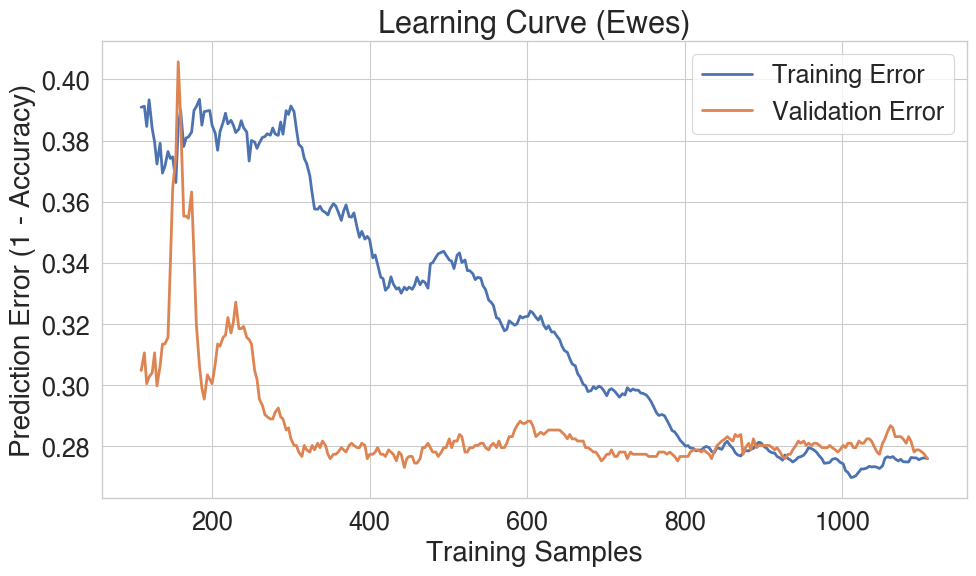

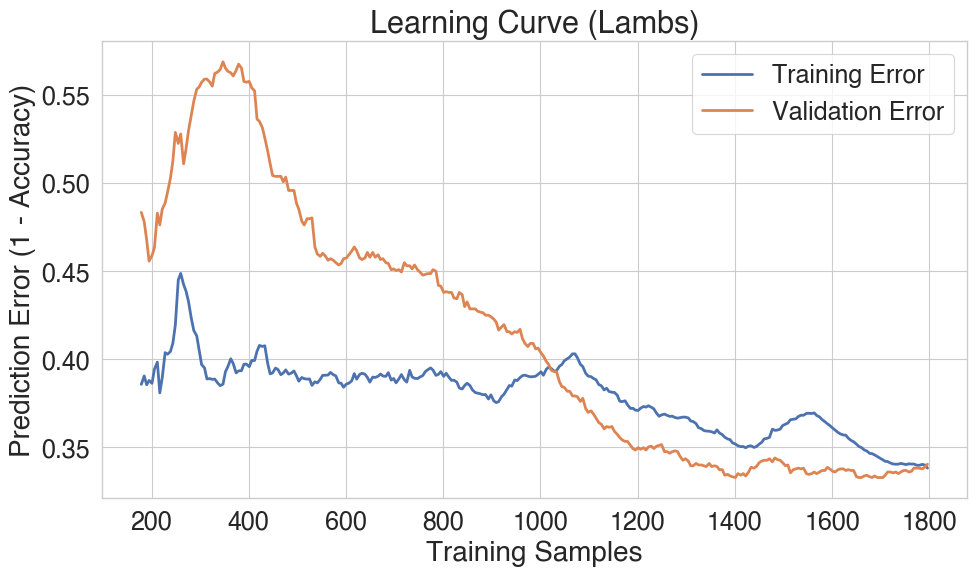

In [39]:
# Preprocess data for both datasets using your function
ewes_df = preprocess_data(ewes_df, 'Unnamed: 0', 'group', {'minus': 0, 'plus': 1})
lambs_df = preprocess_data(lambs_df, 'Unnamed: 0', 'eweseroconverted', {'never': 0, 'before': 1, 'during': 1})

# Prepare data
data_ewes = ewes_df[repro_predictors_ewes + ['group_binary']].dropna()
X_ewes, y_ewes = data_ewes[repro_predictors_ewes], data_ewes['group_binary']

data_lambs = lambs_df[repro_predictors_lambs + ['eweseroconverted_binary']].dropna()
X_lambs, y_lambs = data_lambs[repro_predictors_lambs], data_lambs['eweseroconverted_binary']

# CV and pipeline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, max_iter=5000, solver='liblinear'))

# --- Function: Plot only learning curves ---
def plot_learning_curve(X, y, label, prefix):
    train_sizes, train_scores, test_scores = learning_curve(
        pipe, X, y, cv=cv, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 300), n_jobs=-1, random_state=42)

    train_err = 1 - np.mean(train_scores, axis=1)
    test_err = 1 - np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_err, lw=2, ms=8, label="Training Error")
    plt.plot(train_sizes, test_err, lw=2, ms=8, label="Validation Error")
    plt.title(f"Learning Curve ({label})", fontsize=22, weight='bold')
    plt.xlabel("Training Samples", fontsize=20)
    plt.ylabel("Prediction Error (1 - Accuracy)", fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(loc="best", fontsize=18)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{prefix}_LearningCurve.png", dpi=300)
    plt.show()

# Plot learning curves
plot_learning_curve(X_ewes, y_ewes, "Ewes", "/Users/davidcalleja/Desktop/THESIS/analysis/figures/Ewes")
plot_learning_curve(X_lambs, y_lambs, "Lambs", "/Users/davidcalleja/Desktop/THESIS/analysis/figures/Lambs")

Learning curve: since both errors converge as training size increases, it suggests a well-balanced model that generalizes well. Indicative that collecting more data might not improve performance significantly